<a href="https://colab.research.google.com/github/Hamerson-jhoel/Teoria_de_senales/blob/main/QUIZ/quiz_7_11_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HAMERSON PIARPUEZAN

# QUIZ

**Banda Base:**  
$d = [d_i] \in \mathbb{R}^8  $ →  8 símbolos  

\[
$d_i \rightarrow a_i$
\]

\[
$a_i \in \{a_0, a_1\}$
\]

\[
$a_i V_i(t)\cos(\omega_0 t + \phi_i(t)) \quad \forall t \in T$
\]

\[
$V_i(t) = \text{rect}_T(t) \quad \forall i$
\]

\[
$phi_i(t) = 0 \quad \forall i$
\[
$phi_i(t) = 2i - 1$
\]
$

primeras 20 muestras de señal:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

figura guardada en: /content/digital_signal.png


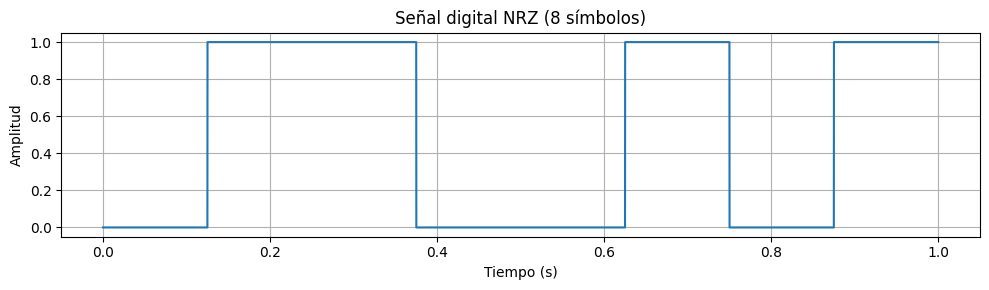

In [ ]:
# Generador de señal digital a partir de 8 símbolos (sin caas_jupyter_tools)
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros que puedes editar ---
d = np.array([0,1,1,0,0,1,0,1])  # 8 símbolos
Tb = 0.125     # duración de símbolo
fs = 20000      # frecuencia de muestreo
sps = int(fs * Tb)   # samples per symbol
# ------------------------------------

# Construcción de la señal NRZ
t_symbol = np.linspace(0, Tb, sps, endpoint=False)
time = np.concatenate([t_symbol + i*Tb for i in range(len(d))])
signal = np.repeat(d, sps)

# Plot
fig, ax = plt.subplots(figsize=(10,3))
ax.plot(time, signal)
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Amplitud')
ax.set_title('Señal digital NRZ (8 símbolos)')
ax.grid(True)
plt.tight_layout()

fig_path = '/content/digital_signal.png'
fig.savefig(fig_path)

print("primeras 20 muestras de señal:")
print(signal[:20])
print()
print("figura guardada en:", fig_path)

Figura RF guardada: /content/rf_signal.png


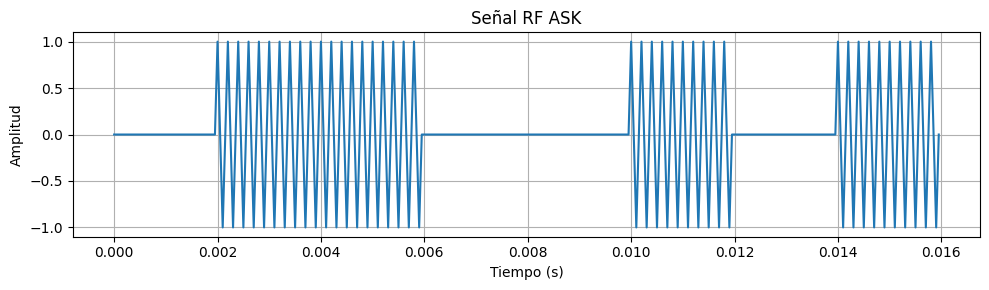

In [ ]:
# Señal RF ASK a partir de la señal digital anterior
import numpy as np
import matplotlib.pyplot as plt

# Señal digital baseband
d = np.array([0,1,1,0,0,1,0,1])      # símbolos
Tb = 0.002                           # duración símbolo
fs = 20000                           # Hz
sps = int(fs * Tb)                   # samples/symbol

# Pulsos rectangulares (Vi(t)=rect)
t_symbol = np.linspace(0, Tb, sps, endpoint=False)
time = np.concatenate([t_symbol + i*Tb for i in range(len(d))])
base = np.repeat(d, sps)

# Mapeo a amplitud RF
a0 = 0.0
a1 = 1.0
a = d.copy().astype(float)
a[a==0]=a0
a[a==1]=a1
a_rep = np.repeat(a, sps)

# RF carrier
fc = 5000    # 5 kHz portadora
w0 = 2*np.pi*fc

# fi(t)=0
fi = 0

# Señal RF
rf = a_rep * np.cos(w0*time + fi)

# Plot
fig, ax = plt.subplots(figsize=(10,3))
ax.plot(time, rf)
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Amplitud")
ax.set_title("Señal RF ASK")
ax.grid(True)
plt.tight_layout()

rf_fig = "/content/rf_signal.png"
fig.savefig(rf_fig)

print("Figura RF guardada:", rf_fig)

Asunción: i toma valores 1..N. Por tanto fi para cada símbolo (radianes):
  símbolo 1: fi = 1.000 rad
  símbolo 2: fi = 3.000 rad
  símbolo 3: fi = 5.000 rad
  símbolo 4: fi = 7.000 rad
  símbolo 5: fi = 9.000 rad
  símbolo 6: fi = 11.000 rad
  símbolo 7: fi = 13.000 rad
  símbolo 8: fi = 15.000 rad

Primeras 40 muestras de la señal RF:
[ 0. -0. -0.  0.  0. -0. -0.  0.  0. -0. -0.  0.  0. -0. -0.  0.  0. -0.
 -0.  0.  0. -0. -0.  0.  0. -0. -0.  0.  0. -0. -0.  0.  0. -0. -0.  0.
  0. -0. -0.  0.]

Figura guardada en: /content/rf_with_phase.png


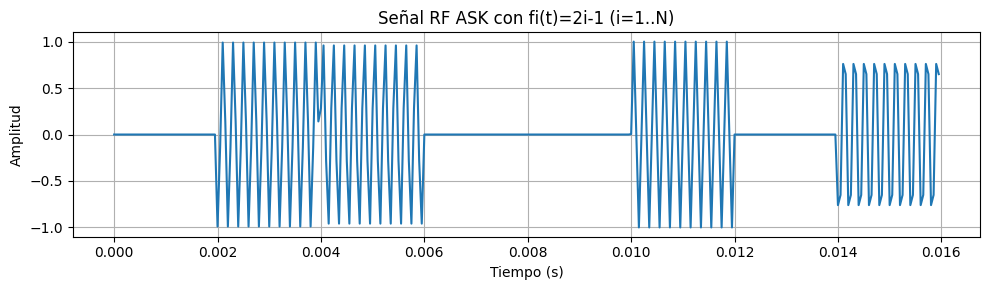

In [ ]:
# Señal RF ASK con fase por símbolo fi(t) = 2*i - 1 (asumimos i empieza en 1)
import numpy as np
import matplotlib.pyplot as plt

# Parámetros (puedes editar)
d = np.array([0,1,1,0,0,1,0,1])   # símbolos (8)
Tb = 0.002                        # duración símbolo [s]
fs = 20000                        # frecuencia de muestreo [Hz]
sps = int(fs*Tb)                  # samples por símbolo
a0 = 0.0                          # amplitud para símbolo 0 (OOK)
a1 = 1.0                          # amplitud para símbolo 1
fc = 5000                         # frecuencia portadora [Hz]
w0 = 2*np.pi*fc

# Tiempo y baseband
t_symbol = np.linspace(0, Tb, sps, endpoint=False)
time = np.concatenate([t_symbol + i*Tb for i in range(len(d))])
a = np.where(d==1, a1, a0)        # mapeo ai
a_rep = np.repeat(a, sps)

# Definimos phi por símbolo: fi = 2*i - 1
# IMPORTANTE: asumimos i = 1..N (no 0..N-1). Si prefieres que i empiece en 0, dime.
N = len(d)
phi_symbols = np.array([2*(i+1) - 1 for i in range(N)])  # i+1 para empezar en 1
phi_rep = np.repeat(phi_symbols, sps)

# Generamos la señal RF: ai * rect(t) * cos(w0*t + phi_i)
rf = a_rep * np.cos(w0*time + phi_rep)

# Guardar figura y mostrar resumen
fig, ax = plt.subplots(figsize=(10,3))
ax.plot(time, rf)
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Amplitud')
ax.set_title('Señal RF ASK con fi(t)=2i-1 (i=1..N)')
ax.grid(True)
plt.tight_layout()

fig_path = '/content/rf_with_phase.png'
fig.savefig(fig_path)

# Información que muestro al usuario
print("Asunción: i toma valores 1..N. Por tanto fi para cada símbolo (radianes):")
for idx, ph in enumerate(phi_symbols, start=1):
    print(f"  símbolo {idx}: fi = {ph:.3f} rad")

print("\nPrimeras 40 muestras de la señal RF:")
print(np.round(rf[:40], 4))

print(f"\nFigura guardada en: {fig_path}")

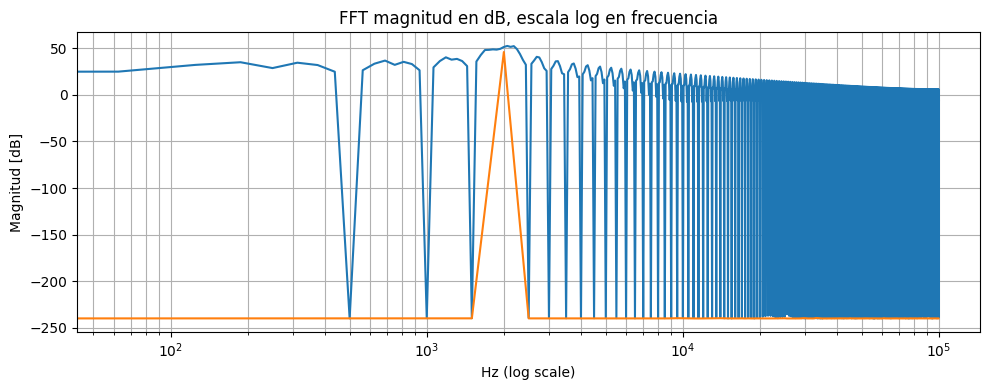

In [ ]:
# Replot FFT in dB and log scale
import numpy as np
import matplotlib.pyplot as plt

# We reuse previous data if exists in session; if not, regenerate minimally
try:
    F, M
    F1, M1
except NameError:
    # minimal regeneration (same parameters as last code)
    d = np.array([0,1,1,0,0,1,0,1])
    T  = 0.002
    fs = 200000
    Ts = 1/fs
    N  = len(d)
    a0=0; a1=1
    ai = np.where(d==1,a1,a0)
    Wo = 2*np.pi*2000
    fi = np.array([2*(i+1)-1 for i in range(N)])
    t = np.arange(0, N*T, Ts)
    s = np.zeros_like(t)
    for i in range(N):
        idx = np.where((t>=i*T)&(t<(i+1)*T))[0]
        s[idx]=ai[i]*np.cos(Wo*(t[idx]-i*T)+fi[i])
    i_sym=1
    t1=np.arange(0,T,Ts)
    s1=ai[i_sym]*np.cos(Wo*t1+fi[i_sym])
    def mag_fft(x,fs):
        Nfft=len(x)
        f=np.fft.fftfreq(Nfft,1/fs)
        X=np.fft.fft(x)
        return f[:Nfft//2], np.abs(X[:Nfft//2])
    F1,M1=mag_fft(s1,fs)
    F,M =mag_fft(s ,fs)

# dB conversion
M_db  = 20*np.log10(M  +1e-12)
M1_db = 20*np.log10(M1 +1e-12)

plt.figure(figsize=(10,4))
plt.semilogx(F, M_db)
plt.semilogx(F1,M1_db)
plt.xlabel("Hz (log scale)")
plt.ylabel("Magnitud [dB]")
plt.title("FFT magnitud en dB, escala log en frecuencia")
plt.grid(True, which='both')
plt.tight_layout()
plt.show()


Figura guardada en: /content/fft_normalized_lobes.png
Nota: las curvas están normalizadas a su máximo individual (0 dB).


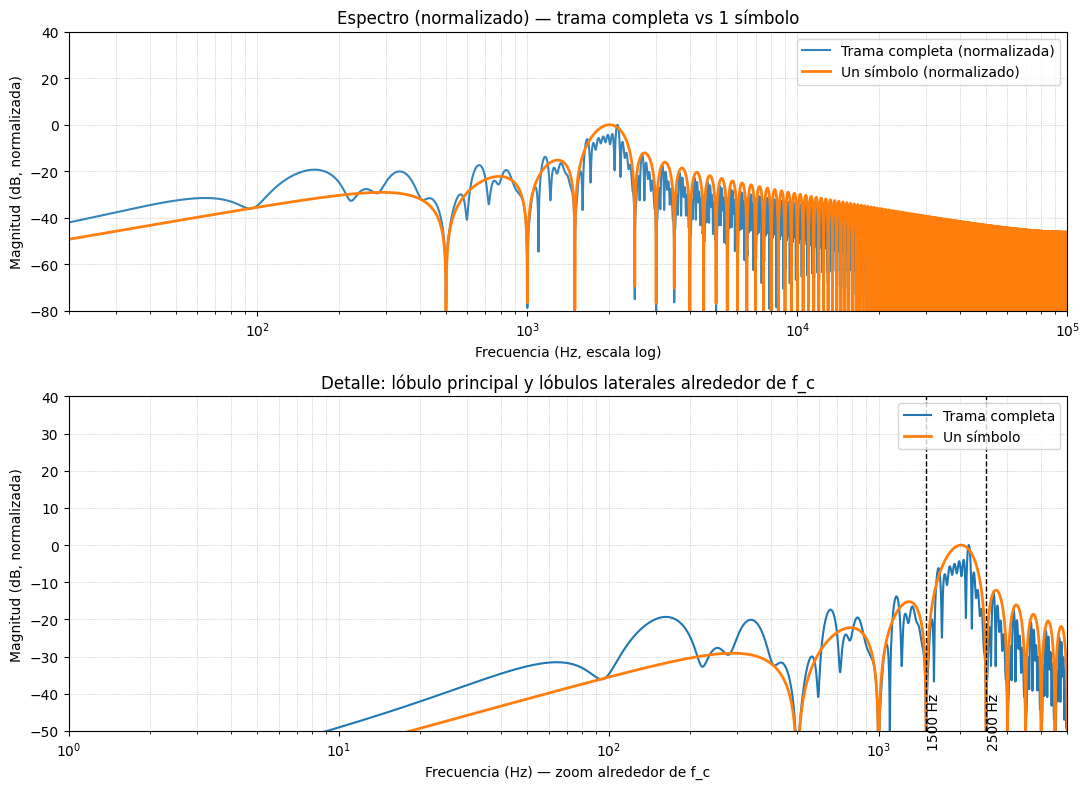

In [ ]:
# FFT normalizada y visualización del lóbulo principal y lóbulos laterales
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

# --- Parámetros (mismos que antes) ---
d = np.array([0,1,1,0,0,1,0,1])
T  = 0.002         # duración símbolo [s]
fs = 200000        # frecuencia de muestreo [Hz]
Ts = 1/fs
Nsym = len(d)
a0, a1 = 0.0, 1.0
ai = np.where(d==1, a1, a0)
fc = 2000          # frecuencia portadora [Hz]
w0 = 2*np.pi*fc

# fases por símbolo (como antes: fi = 2*i-1, i=1..N)
phi = np.array([2*(i+1)-1 for i in range(Nsym)])

# tiempo total y señales
t = np.arange(0, Nsym*T, Ts)
s = np.zeros_like(t)
for i in range(Nsym):
    idx = np.where((t>=i*T)&(t<(i+1)*T))[0]
    s[idx] = ai[i] * np.cos(w0*(t[idx]-i*T) + phi[i])

# seleccionar un símbolo (ej. segundo símbolo i=1, índice base 0)
i_sym = 1
t1 = np.arange(0, T, Ts)
s1 = ai[i_sym] * np.cos(2*np.pi*fc*t1 + phi[i_sym])

# --- FFT con zero-padding para buena resolución ---
Nfft = 262144  # potencia de 2 para buena resolución
def compute_fft(x, fs, Nfft):
    X = np.fft.fft(x, n=Nfft)
    f = np.fft.fftfreq(Nfft, 1/fs)
    # solo la mitad positiva
    pos = f >= 0
    return f[pos], np.abs(X[pos])

f_s, M_s = compute_fft(s, fs, Nfft)
f_1, M_1 = compute_fft(s1, fs, Nfft)

# Normalización (cada espectro a su propio máximo -> 0 dB)
M_s_db  = 20*np.log10(M_s / (M_s.max() + 1e-16) + 1e-16)
M_1_db  = 20*np.log10(M_1 / (M_1.max() + 1e-16) + 1e-16)

# Para resaltar lóbulo principal: posiciones de primeros nulos teóricos alrededor de fc
# Para rect_T(t), sinc zeros en (f-fc)T = m => f = fc + m/T
first_nulls = [fc - 1.0/T, fc + 1.0/T]

# --- Ploteo: panel completo y zoom al lóbulo principal ---
fig, (ax_full, ax_zoom) = plt.subplots(2,1, figsize=(11,8), gridspec_kw={'height_ratios':[1,1.2]})

# Full spectrum (dB) - semilogx
ax_full.semilogx(f_s, M_s_db, label='Trama completa (normalizada)', alpha=0.9)
ax_full.semilogx(f_1, M_1_db, label='Un símbolo (normalizado)', linewidth=2)
ax_full.set_xlim(20, fs/2)
ax_full.set_ylim(-80, 40)
ax_full.set_xlabel('Frecuencia (Hz, escala log)')
ax_full.set_ylabel('Magnitud (dB, normalizada)')
ax_full.set_title('Espectro (normalizado) — trama completa vs 1 símbolo')
ax_full.grid(True, which='both', ls=':', lw=0.5)
ax_full.legend(loc='upper right')

# Zoom: alrededor de fc para mostrar lóbulo principal y algunos laterales
fmin = max(1, fc - 6*(1.0/T))
fmax = fc + 6*(1.0/T)
ax_zoom.semilogx(f_s, M_s_db, label='Trama completa')
ax_zoom.semilogx(f_1, M_1_db, label='Un símbolo', linewidth=2)
ax_zoom.set_xlim(fmin, fmax)
ax_zoom.set_ylim(-50, 40)
ax_zoom.set_xlabel('Frecuencia (Hz) — zoom alrededor de f_c')
ax_zoom.set_ylabel('Magnitud (dB, normalizada)')
ax_zoom.set_title('Detalle: lóbulo principal y lóbulos laterales alrededor de f_c')
ax_zoom.grid(True, which='both', ls=':', lw=0.5)
ax_zoom.legend(loc='upper right')

# marcar los primeros nulos teóricos
for fn in first_nulls:
    ax_zoom.axvline(fn, color='k', linestyle='--', linewidth=1)
    ax_zoom.text(fn*1.01, -55, f'{fn:.0f} Hz', rotation=90, va='bottom')

# guardar figura
fig.tight_layout()
out_path = '/content/fft_normalized_lobes.png'
fig.savefig(out_path, dpi=200)

print("Figura guardada en:", out_path)
print("Nota: las curvas están normalizadas a su máximo individual (0 dB).")

In [ ]:
import numpy as np

# --------------------------------------------
# parámetros
# --------------------------------------------
Fs = 1e6         # Hz  (sampling)
T  = 1e-3        # 1 ms  (duración de un símbolo)
fc = 2e3         # Hz
N  = int(T*Fs)

# --------------------------------------------
# construir un pulso (1 símbolo)
# --------------------------------------------
t = np.arange(N)/Fs
p = np.cos(2*np.pi*fc*t)

# --------------------------------------------
# ancho de banda (teórico) lóbulo principal
# zeros de sinc: fc ± 1/T
# --------------------------------------------
BW = 2*(1/T)     # distancia de primer cero a primer cero
                 # (anchura entre los dos primeros nulos)

print("Duración de 1 símbolo T = ", T, " segundos")
print("Ancho de banda del lóbulo principal = ", BW, " Hz")


Duración de 1 símbolo T =  0.001  segundos
Ancho de banda del lóbulo principal =  2000.0  Hz


Tiempo de símbolo = 0.125 segundos
Nulos principales teóricos deben estar en f = fc ± 1/T
fc = 2000 Hz
Nulo izquierdo  = 1992.0 Hz
Nulo derecho    = 2008.0 Hz


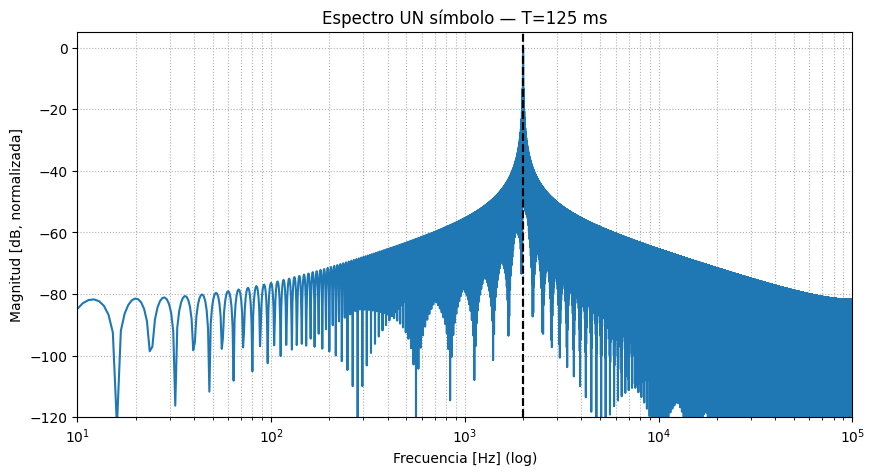

In [ ]:
# FFT espectro para UN símbolo con T = 125 ms

import numpy as np
import matplotlib.pyplot as plt

# --- nuevo parámetro solicitado ---
T = 0.125      # 125 ms por símbolo
fs = 200000    # Hz (mantengo el mismo sampling para buena resolución)
fc = 2000      # Hz

N = int(T*fs)
t = np.arange(N)/fs

# símbolo RF
s = np.cos(2*np.pi*fc*t)

# FFT
Nfft = 262144
S = np.fft.fft(s, Nfft)
freqs = np.fft.fftfreq(Nfft,1/fs)
pos = freqs>=0
freqs = freqs[pos]
S = np.abs(S[pos])

# Normalizar a 0 dB
Sdb = 20*np.log10(S/np.max(S) + 1e-16)

# donde están los nulos teóricos del sinc principal
# fc ± 1/T
f_left  = fc - 1/T
f_right = fc + 1/T

# gráfica
plt.figure(figsize=(10,5))
plt.semilogx(freqs, Sdb)
plt.axvline(f_left, color='k', linestyle='--')
plt.axvline(f_right, color='k', linestyle='--')
plt.ylim(-120,5)
plt.xlim(10, fs/2)
plt.grid(True, which='both', ls=':')
plt.xlabel("Frecuencia [Hz] (log)")
plt.ylabel("Magnitud [dB, normalizada]")
plt.title("Espectro UN símbolo — T=125 ms")

print("Tiempo de símbolo =",T,"segundos")
print("Nulos principales teóricos deben estar en f = fc ± 1/T")
print("fc =",fc,"Hz")
print("Nulo izquierdo  =",f_left,"Hz")
print("Nulo derecho    =",f_right,"Hz")

plt.show()


In [ ]:
# cálculo automático de ΔΩ para un símbolo rectangular
import numpy as np

# --- usar el mismo T que estamos usando ---
T = 0.125  # 125 ms

# medio lóbulo ΔΩ_half = 2π * (1/T)
deltaOmega_half = 2*np.pi*(1/T)

# lóbulo completo ΔΩ_full = 2π * (2/T)
deltaOmega_full = 2*np.pi*(2/T)

print("Tiempo de símbolo T =",T,"seg")
print("ΔΩ_half  (centro → primer nulo)     = ",deltaOmega_half," rad/s")
print("ΔΩ_full  (nulo izq → nulo der)     = ",deltaOmega_full," rad/s")


Tiempo de símbolo T = 0.125 seg
ΔΩ_half  (centro → primer nulo)     =  50.26548245743669  rad/s
ΔΩ_full  (nulo izq → nulo der)     =  100.53096491487338  rad/s


In [ ]:
import numpy as np

# parametros
T = 0.125      # s
Wc = 2*np.pi*1000    # 1 kHz en rad/s ejemplo
Wp = 3*Wc     # lo que pediste

# ancho teórico del lóbul principal
deltaW = 4*np.pi/T
deltaW_prime = deltaW     # igual (trasladar no estira)

ratio = deltaW_prime/deltaW

print("T =", T, "s")
print("Wc =", Wc, "rad/s")
print("W'c =", Wp, "rad/s")
print("deltaW =", deltaW, "rad/s")
print("deltaW' =", deltaW_prime, "rad/s")
print("ratio ΔW'/ΔW =", ratio)


T = 0.125 s
Wc = 6283.185307179586 rad/s
W'c = 18849.55592153876 rad/s
deltaW = 100.53096491487338 rad/s
deltaW' = 100.53096491487338 rad/s
ratio ΔW'/ΔW = 1.0


In [ ]:
import numpy as np

# Duración del pulso rectangular (segundos)
T = 0.125  # 200 microsegundos

# Cálculo de Δω y Δf
delta_w = 2 * np.pi / T        # rad/s
delta_f = delta_w / (2 * np.pi)  # Hz

print(f"Δω = {delta_w:.4e} rad/s")
print(f"Δf = {delta_f:.2f} Hz")

Δω = 5.0265e+01 rad/s
Δf = 8.00 Hz


In [ ]:
# Medir la máxima amplitud del primer lóbulo lateral (lado derecho e izquierdo) para 1 símbolo
import numpy as np

# Parámetros (usar los del ejercicio)
T = 0.125          # s
fs = 200000        # Hz (muestreo alto para buena resolución)
fc = 2000          # Hz (portadora)
Ts = 1/fs

# construir un símbolo: cos(2πfc t) sobre duración T
t = np.arange(0, T, Ts)
s = np.cos(2*np.pi*fc*t)

# FFT con zero-padding para resolución fina
Nfft = 262144
S = np.fft.fft(s, n=Nfft)
f = np.fft.fftfreq(Nfft, 1/fs)
pos = f >= 0
f_pos = f[pos]
S_pos = np.abs(S[pos])

# normalizamos respecto al pico del lóbulo principal
peak_idx = np.argmax(S_pos)
peak_freq = f_pos[peak_idx]
peak_val = S_pos[peak_idx]

# límites del lóbulo principal teóricos
f_null_left  = fc - 1.0/T
f_null_right = fc + 1.0/T

# índices de interés
idx_null_right = np.searchsorted(f_pos, f_null_right)
idx_null_left  = np.searchsorted(f_pos, f_null_left)

# buscar primer lóbulo lateral derecho: buscar máximo entre idx_null_right y idx_null_right + window_bins
# elegimos ventana de búsqueda = 4*(1/T) en frecuencia para asegurar capturar el primer lóbulo lateral
band_width_hz = 4.0*(1.0/T)
idx_band_end = np.searchsorted(f_pos, f_null_right + band_width_hz)

if idx_null_right < len(S_pos):
    side_right_idx = idx_null_right + np.argmax(S_pos[idx_null_right:idx_band_end])
    side_right_freq = f_pos[side_right_idx]
    side_right_val = S_pos[side_right_idx]
else:
    side_right_idx = None
    side_right_freq = np.nan
    side_right_val = np.nan

# buscar primer lóbulo lateral izquierdo: buscar máximo entre idx_null_left - window_bins y idx_null_left
idx_band_start = np.searchsorted(f_pos, f_null_left - band_width_hz)
if idx_band_start < 0:
    idx_band_start = 0
if idx_null_left > 0:
    segment = S_pos[idx_band_start:idx_null_left]
    if segment.size>0:
        rel_idx = np.argmax(segment)
        side_left_idx = idx_band_start + rel_idx
        side_left_freq = f_pos[side_left_idx]
        side_left_val = S_pos[side_left_idx]
    else:
        side_left_idx = None
        side_left_freq = np.nan
        side_left_val = np.nan
else:
    side_left_idx = None
    side_left_freq = np.nan
    side_left_val = np.nan

# convertir a dB relativo al pico principal
eps = 1e-16
side_right_db = 20*np.log10((side_right_val+eps)/(peak_val+eps))
side_left_db = 20*np.log10((side_left_val+eps)/(peak_val+eps))

# Mostrar resultados
print("Parámetros: T = {:.6f} s, fc = {} Hz, 1/T = {:.3f} Hz".format(T, fc, 1.0/T))
print("Pico principal: freq = {:.3f} Hz, magnitud = {:.6e} (linear, FFT mag)".format(peak_freq, peak_val))
print("--- Primer lóbulo lateral derecho ---")
print("  freq ≈ {:.3f} Hz".format(side_right_freq))
print("  magnitud = {:.6e} (linear FFT magnitude)".format(side_right_val))
print("  magnitud = {:.3f} dB (relativa al pico principal)".format(side_right_db))
print("--- Primer lóbulo lateral izquierdo ---")
print("  freq ≈ {:.3f} Hz".format(side_left_freq))
print("  magnitud = {:.6e} (linear FFT magnitude)".format(side_left_val))
print("  magnitud = {:.3f} dB (relativa al pico principal)".format(side_left_db))


Parámetros: T = 0.125000 s, fc = 2000 Hz, 1/T = 8.000 Hz
Pico principal: freq = 1999.664 Hz, magnitud = 1.246278e+04 (linear, FFT mag)
--- Primer lóbulo lateral derecho ---
  freq ≈ 2011.108 Hz
  magnitud = 2.699077e+03 (linear FFT magnitude)
  magnitud = -13.288 dB (relativa al pico principal)
--- Primer lóbulo lateral izquierdo ---
  freq ≈ 1988.220 Hz
  magnitud = 2.684132e+03 (linear FFT magnitude)
  magnitud = -13.336 dB (relativa al pico principal)


Parámetros: T = 0.125000 s, fc = 2000 Hz, alpha = 1.00
--- Ventana Raised-Cosine (alpha=1.00) aplicada al pulso ---
Pico (windowed) freq ≈ 1994.324 Hz
Primer lóbulo lateral derecho: freq = 2008.057 Hz, nivel = -2.259 dB (rel. al pico)
Primer lóbulo lateral izquierdo:  freq = 1991.272 Hz, level = -3.751 dB (rel. al pico)

--- Pulso rectangular (referencia) ---
Pico (rect) freq ≈ 1999.664 Hz
Primer lóbulo lateral derecho (rect): freq = 2011.108 Hz, nivel = -13.288 dB (rel. al pico)
Primer lóbulo lateral izquierdo (rect):  freq = 1988.220 Hz, nivel = -13.336 dB (rel. al pico)

Figura guardada en: /content/raised_cosine_alpha_1.00_vs_rect_sidelobes.png


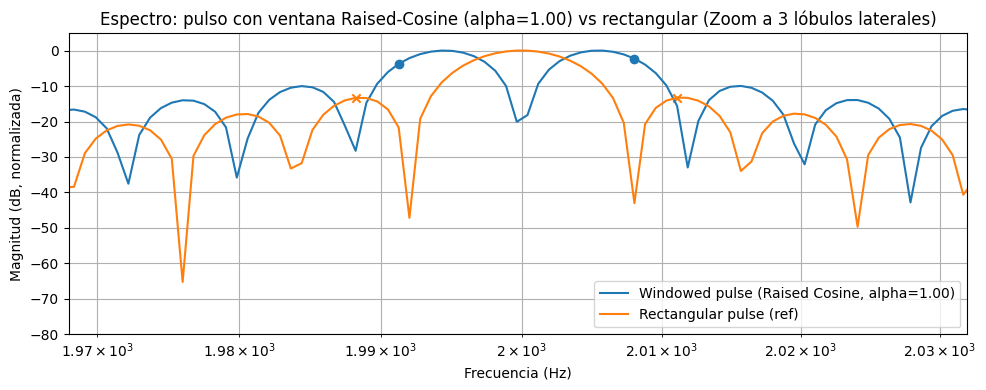

In [ ]:
# Aplicar una ventana "Raised Cosine" (general) al pulso, calcular FFT y medir la magnitud del primer lóbulo lateral
import numpy as np
import matplotlib.pyplot as plt

# Parámetros (mismos que veníamos usando)
T = 0.125        # duración símbolo [s]
fs = 200000      # muestreo [Hz]
fc = 2000        # portadora [Hz]
Ts = 1/fs

# --- Parámetro para el Raised Cosine ---
alpha = 1 # Roll-off factor (0 <= alpha <= 1) - Puedes cambiar este valor

# tiempo y pulso base (rectangular)
t = np.arange(0, T, Ts)
rect = np.ones_like(t)

# Ventana "raised cosine" sobre la duración del símbolo
N = len(t)
n = np.arange(N)
# Fórmula general para Raised Cosine window
# Note: For alpha=1, this simplifies to the Hann window: 0.5 * (1 - cos(2*pi*n/(N-1)))
w = (1 - alpha + alpha * np.cos(np.pi * n / (N-1))) / 2


# Pulso moldeado: rect * w
pulse_windowed = rect * w

# Señal RF: multiplicamos por la portadora (con fase 0)
carrier = np.cos(2 * np.pi * fc * t)
s_windowed = pulse_windowed * carrier

# Para comparar, pulso rectangular sin ventana (como referencia)
s_rect = rect * carrier

# FFT (zero-padding para buena resolución)
Nfft = 262144
def compute_fft_mag(x):
    X = np.fft.fft(x, n=Nfft)
    f = np.fft.fftfreq(Nfft, 1/fs)
    pos = f >= 0
    return f[pos], np.abs(X[pos])

f_w, M_w = compute_fft_mag(s_windowed)
f_r, M_r = compute_fft_mag(s_rect)

# Normalizar ambos respecto a su pico individual (y en dB)
eps = 1e-16
M_w_db = 20*np.log10(M_w / (M_w.max() + eps) + eps)
M_r_db = 20*np.log10(M_r / (M_r.max() + eps) + eps)

# Identificar pico principal alrededor de fc
idx_peak_w = np.argmax(M_w[(f_w> (fc-50)) & (f_w < (fc+50))]) + np.searchsorted(f_w, fc-50)
idx_peak_r = np.argmax(M_r[(f_r> (fc-50)) & (f_r < (fc+50))]) + np.searchsorted(f_r, fc-50)
peak_freq_w = f_w[idx_peak_w]
peak_freq_r = f_r[idx_peak_r]


# Encontrar nulos teóricos para rect: fc ± 1/T
f_null_left = fc - 1.0/T
f_null_right = fc + 1.0/T

# Buscar primer lóbulo lateral derecho: buscar máximo entre idx_null_right and idx_null_right + window_bins
idx_null_right = np.searchsorted(f_w, f_null_right)
idx_null_left  = np.searchsorted(f_w, f_null_left)

# set search window width (in Hz)
search_width_hz = 4.0 * (1.0/T)   # como antes
idx_band_end = np.searchsorted(f_w, f_null_right + search_width_hz)
idx_band_start = np.searchsorted(f_w, f_null_left - search_width_hz)
if idx_band_start < 0:
    idx_band_start = 0

# Right sidelobe for windowed pulse
if idx_null_right < len(M_w):
    seg = M_w[idx_null_right:idx_band_end]
    if seg.size>0:
        rel = np.argmax(seg)
        idx_side_right_w = idx_null_right + rel
        freq_side_right_w = f_w[idx_side_right_w]
        mag_side_right_w = M_w[idx_side_right_w]
        mag_side_right_w_db = 20*np.log10((mag_side_right_w+eps)/(M_w.max()+eps))
    else:
        freq_side_right_w = np.nan; mag_side_right_w_db = np.nan
else:
    freq_side_right_w = np.nan; mag_side_right_w_db = np.nan

# Left sidelobe for windowed pulse
if idx_null_left > 0:
    segL = M_w[idx_band_start:idx_null_left]
    if segL.size>0:
        relL = np.argmax(segL)
        idx_side_left_w = idx_band_start + relL
        freq_side_left_w = f_w[idx_side_left_w]
        mag_side_left_w = M_w[idx_side_left_w]
        mag_side_left_w_db = 20*np.log10((mag_side_left_w+eps)/(M_w.max()+eps))
    else:
        freq_side_left_w = np.nan; mag_side_left_w_db = np.nan
else:
    freq_side_left_w = np.nan; mag_side_left_w_db = np.nan

# Hacer lo mismo para pulso rectangular (referencia)
if idx_null_right < len(M_r):
    segr = M_r[idx_null_right:np.searchsorted(f_r, f_null_right + search_width_hz)]
    if segr.size>0:
        relr = np.argmax(segr)
        idx_side_right_r = idx_null_right + relr
        freq_side_right_r = f_r[idx_side_right_r]
        mag_side_right_r = M_r[idx_side_right_r]
        mag_side_right_r_db = 20*np.log10((mag_side_right_r+eps)/(M_r.max()+eps))
    else:
        freq_side_right_r = np.nan; mag_side_right_r_db = np.nan
else:
    freq_side_right_r = np.nan; mag_side_right_r_db = np.nan

if idx_null_left > 0:
    segrL = M_r[idx_band_start:idx_null_left]
    if segrL.size>0:
        relrL = np.argmax(segrL)
        idx_side_left_r = idx_band_start + relrL
        freq_side_left_r = f_r[idx_band_start + relrL]
        mag_side_left_r = M_r[idx_band_start + relrL]
        mag_side_left_r_db = 20*np.log10((mag_side_left_r+eps)/(M_r.max()+eps))
    else:
        freq_side_left_r = np.nan; mag_side_left_r_db = np.nan
else:
    freq_side_left_r = np.nan; mag_side_left_r_db = np.nan


# Imprimir resultados
print("Parámetros: T = {:.6f} s, fc = {} Hz, alpha = {:.2f}".format(T, fc, alpha))
print("--- Ventana Raised-Cosine (alpha={:.2f}) aplicada al pulso ---".format(alpha))
print("Pico (windowed) freq ≈ {:.3f} Hz".format(peak_freq_w))
print("Primer lóbulo lateral derecho: freq = {:.3f} Hz, nivel = {:.3f} dB (rel. al pico)".format(freq_side_right_w, mag_side_right_w_db))
print("Primer lóbulo lateral izquierdo:  freq = {:.3f} Hz, level = {:.3f} dB (rel. al pico)".format(freq_side_left_w, mag_side_left_w_db))
print()
print("--- Pulso rectangular (referencia) ---")
print("Pico (rect) freq ≈ {:.3f} Hz".format(peak_freq_r))
print("Primer lóbulo lateral derecho (rect): freq = {:.3f} Hz, nivel = {:.3f} dB (rel. al pico)".format(freq_side_right_r, mag_side_right_r_db))
print("Primer lóbulo lateral izquierdo (rect):  freq = {:.3f} Hz, nivel = {:.3f} dB (rel. al pico)".format(freq_side_left_r, mag_side_left_r_db))

# Graficar ambos espectros superpuestos (dB, log freq) y marcar los picos laterales
plt.figure(figsize=(10,4))
plt.semilogx(f_w, 20*np.log10(M_w/(M_w.max()+eps)+eps), label=f'Windowed pulse (Raised Cosine, alpha={alpha:.2f})')
plt.semilogx(f_r, 20*np.log10(M_r/(M_r.max()+eps)+eps), label='Rectangular pulse (ref)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud (dB, normalizada)')
plt.title(f'Espectro: pulso con ventana Raised-Cosine (alpha={alpha:.2f}) vs rectangular (Zoom a 3 lóbulos laterales)')
plt.grid(True, which='both')
# Adjust x-axis limits to show main lobe and first 3 sidelobes
plt.xlim(max(1, fc - 4*(1.0/T)), fc + 4*(1.0/T))
plt.ylim(-80,5)
# marcar picos laterales
plt.scatter([freq_side_right_w, freq_side_left_w], [mag_side_right_w_db, mag_side_left_w_db], marker='o')
plt.scatter([freq_side_right_r, freq_side_left_r], [mag_side_right_r_db, mag_side_left_r_db], marker='x')
plt.legend()
plt.tight_layout()

# guardar figura
out_path = f'/content/raised_cosine_alpha_{alpha:.2f}_vs_rect_sidelobes.png'
plt.savefig(out_path, dpi=200)

print(f"\nFigura guardada en: {out_path}")

In [ ]:
import numpy as np

# Using parameters from previous cells
# T = 0.125 # Symbol duration in seconds
# fc = 2000 # Carrier frequency in Hz

# Ancho de banda teórico del lóbulo principal (distancia entre los primeros nulos)
# Para un pulso rectangular, los nulos están en fc ± 1/T
BW_main_lobe = 2 * (1/T)  # Hz

# Ancho de banda aproximado del primer lóbulo lateral
# La distancia entre los picos del primer lóbulo lateral y los nulos es aproximadamente 1/T
# El ancho de un lóbulo lateral es aproximadamente 2/T (aunque no es un "ancho de banda" en el mismo sentido que el lóbulo principal)
# Una forma de estimar el "ancho" del primer lóbulo lateral podría ser la distancia entre sus nulos (el segundo y el primer nulo)
# Los nulos están en fc ± m/T, m=1, 2, 3,...
# Primeros nulos: fc-1/T, fc+1/T
# Segundos nulos: fc-2/T, fc+2/T
# El primer lóbulo lateral izquierdo está entre fc-2/T y fc-1/T
# El primer lóbulo lateral derecho está entre fc+1/T y fc+2/T
# El "ancho" de cada primer lóbulo lateral es (fc-1/T) - (fc-2/T) = 1/T, y (fc+2/T) - (fc+1/T) = 1/T

BW_first_sidelobe = 1/T # Hz (aproximado, distancia entre nulos adyacentes)

# delta f (distancia del centro al primer nulo)
delta_f = 1/T # Hz

print(f"Duración del símbolo (T) = {T} s")
print(f"Frecuencia portadora (fc) = {fc} Hz")
print("-" * 30)
print(f"Ancho de banda teórico del lóbulo principal (BW_main_lobe) = {BW_main_lobe:.2f} Hz")
print(f"Ancho aproximado de un lóbulo lateral (BW_first_sidelobe) = {BW_first_sidelobe:.2f} Hz")
print(f"Distancia del centro al primer nulo (delta_f) = {delta_f:.2f} Hz")

Duración del símbolo (T) = 0.125 s
Frecuencia portadora (fc) = 2000 Hz
------------------------------
Ancho de banda teórico del lóbulo principal (BW_main_lobe) = 16.00 Hz
Ancho aproximado de un lóbulo lateral (BW_first_sidelobe) = 8.00 Hz
Distancia del centro al primer nulo (delta_f) = 8.00 Hz


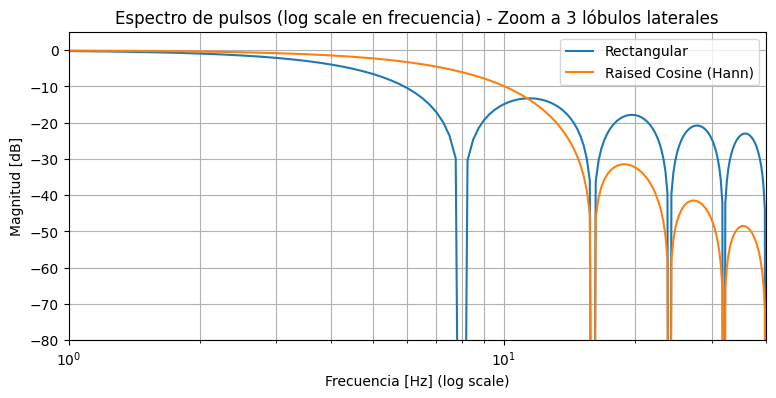

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
T = 0.125  # duración del símbolo en segundos
fs = 50000  # frecuencia de muestreo, alta para mejor espectro
N = int(T*fs)

t = np.arange(N)/fs

# Pulsos
rect = np.ones(N)
hann = 0.1*(1 - np.cos(2*np.pi*t/T))

# FFT
def fft_db(x):
    # Use zero-padding for better frequency resolution in the plot
    Nfft_plot = 200000
    X = np.fft.fftshift(np.fft.fft(x, Nfft_plot))
    X_db = 20*np.log10(np.abs(X)/np.max(np.abs(X))+1e-12)
    f = np.fft.fftshift(np.fft.fftfreq(Nfft_plot, 1/fs))
    return f, X_db

f_rect, db_rect = fft_db(rect)
f_hann, db_hann = fft_db(hann)

# ZOOM: 3 primeros lóbulos laterales (~ 8Hz,16Hz,24Hz para rectangular)

plt.figure(figsize=(9,4))
# Use semilogx for log scale on x-axis
plt.semilogx(f_rect, db_rect, label='Rectangular')
plt.semilogx(f_hann, db_hann, label='Raised Cosine (Hann)')

# Adjust x-axis limits for log scale to show positive frequencies and the first 3 sidelobes
# The first nulls for the rectangular pulse are at +/- 1/T. Sidelobes are beyond that.
# We want to show up to roughly 3*1/T or a bit more to see the third sidelobe.
# 1/T = 1/0.125 = 8 Hz. So we want to see up to around 3 * 8 = 24 Hz, maybe up to 30-40 Hz.
plt.xlim(1, 40) # Start from 1 Hz to avoid log(0) and show up to 40 Hz
plt.ylim(-80, 5) # Keep y-axis limits reasonable

plt.xlabel("Frecuencia [Hz] (log scale)")
plt.ylabel("Magnitud [dB]")
plt.title("Espectro de pulsos (log scale en frecuencia) - Zoom a 3 lóbulos laterales")
plt.grid(True, which='both') # Show grid for both major and minor ticks
plt.legend()
plt.show()

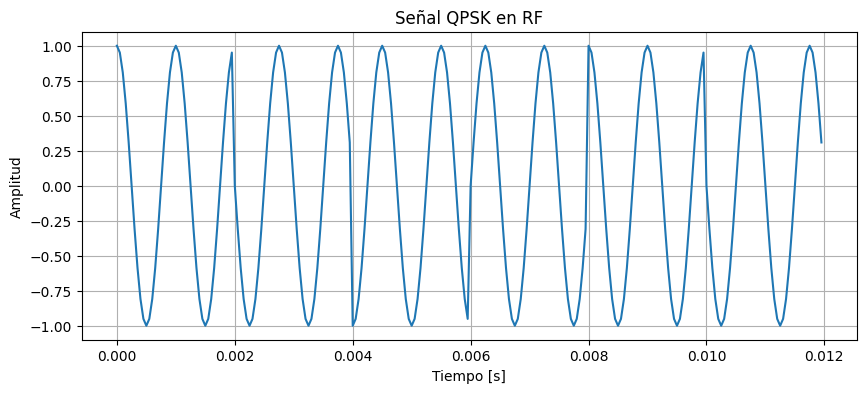

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
d = np.array([0,1,2,3,0,1])  # símbolos
T = 0.002                     # duración símbolo [s]
fs = 20000                    # frecuencia de muestreo
t = np.arange(0, T, 1/fs)     # vector de tiempo por símbolo
f0 = 1000                     # frecuencia portadora

# Mapeo QPSK
mapping = {0: 1, 1: 1j, 2: -1, 3: -1j}
ai = np.array([mapping[di] for di in d])

# Señal RF
s_rf = np.array([])
for a in ai:
    # Descomponer parte real e imaginaria
    s_i = np.real(a)*np.cos(2*np.pi*f0*t) - np.imag(a)*np.sin(2*np.pi*f0*t)
    s_rf = np.concatenate((s_rf, s_i))

# Tiempo total
t_total = np.arange(0, len(d)*T, 1/fs)

# Graficar
plt.figure(figsize=(10,4))
plt.plot(t_total, s_rf)
plt.title("Señal QPSK en RF")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


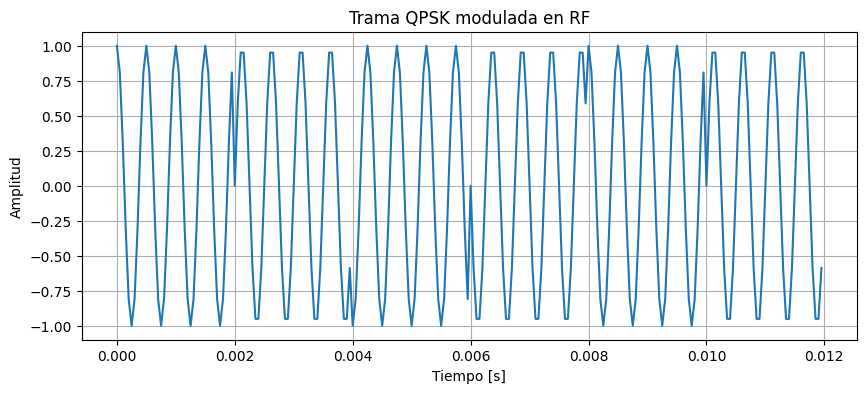

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
ac = np.array([0, 1, 2, 3, 0, 1])  # símbolos QPSK
T = 0.002                           # duración de símbolo [s]
fs = 20000                          # frecuencia de muestreo
fc = 2000                           # frecuencia portadora [Hz]

t_sym = np.arange(0, T, 1/fs)      # vector de tiempo por símbolo

# Inicializar señal RF
s_RF = np.array([])

# Loop para cada símbolo
for a in ac:
    if a == 0:
        s = 1 * np.cos(2*np.pi*fc*t_sym)   # par → coseno positivo
    elif a == 1:
        s = 1 * np.sin(2*np.pi*fc*t_sym)   # impar → seno positivo
    elif a == 2:
        s = -1 * np.cos(2*np.pi*fc*t_sym)  # par → coseno negativo
    elif a == 3:
        s = -1 * np.sin(2*np.pi*fc*t_sym)  # impar → seno negativo
    s_RF = np.concatenate((s_RF, s))

# Tiempo total
t_total = np.arange(0, len(s_RF)/fs, 1/fs)

# Graficar
plt.figure(figsize=(10,4))
plt.plot(t_total, s_RF)
plt.title("Trama QPSK modulada en RF")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


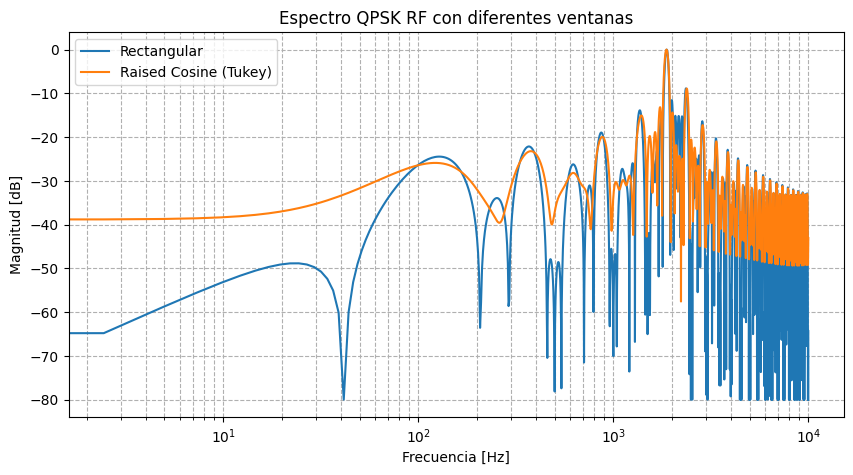

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

# Parámetros de FFT
NFFT = 8192                       # tamaño de la FFT
fs = 20000                         # frecuencia de muestreo

# Ventanas
win_rect = np.ones(len(s_RF))                  # rectangular
beta = 0.25                                   # factor de roll-off para raised cosine
win_rc = windows.tukey(len(s_RF), alpha=beta) # aproximación de Raised Cosine con Tukey

# FFT con ventana rectangular
S_rect = np.fft.fft(s_RF * win_rect, NFFT)
S_rect = np.fft.fftshift(S_rect)             # centrar frecuencia
freq = np.fft.fftshift(np.fft.fftfreq(NFFT, 1/fs))
S_rect_dB = 20*np.log10(np.abs(S_rect)/np.max(np.abs(S_rect)))

# FFT con ventana Raised Cosine (Tukey)
S_rc = np.fft.fft(s_RF * win_rc, NFFT)
S_rc = np.fft.fftshift(S_rc)
S_rc_dB = 20*np.log10(np.abs(S_rc)/np.max(np.abs(S_rc)))

# Limitar el mínimo a -80 dB para mejor visualización
S_rect_dB = np.clip(S_rect_dB, -80, None)
S_rc_dB = np.clip(S_rc_dB, -80, None)

# Graficar
plt.figure(figsize=(10,5))
plt.plot(freq, S_rect_dB, label='Rectangular', linewidth=1.5)
plt.plot(freq, S_rc_dB, label='Raised Cosine (Tukey)', linewidth=1.5)
plt.xscale('log')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.title('Espectro QPSK RF con diferentes ventanas')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


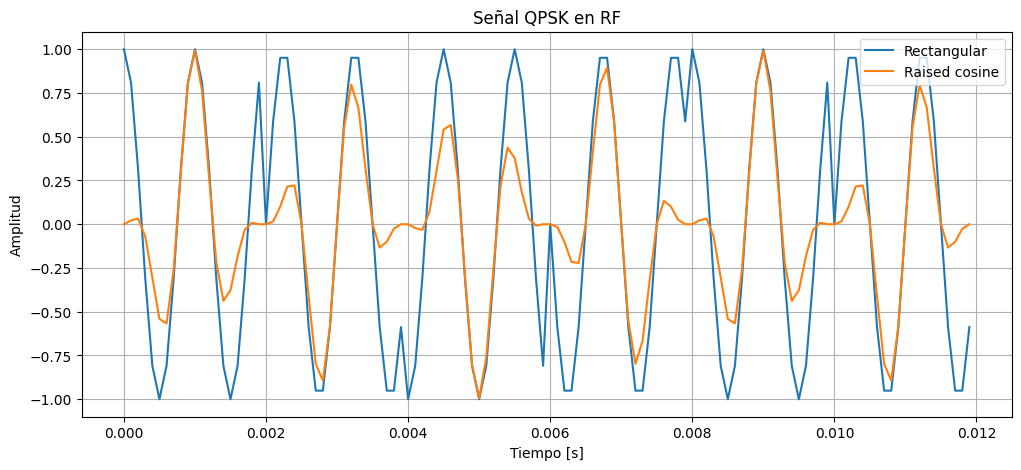

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

# Parámetros
d = np.array([0, 1, 2, 3, 0, 1])  # símbolos QPSK
T = 0.002       # duración símbolo [s]
fs = 10000      # frecuencia de muestreo [Hz]
fc = 1000       # frecuencia de portadora [Hz]

# Mapear símbolos a amplitudes QPSK
mapping = {0: 1, 1: 1j, 2: -1, 3: -1j}
a = np.array([mapping[di] for di in d])

# Tiempo
t = np.arange(0, T*len(d), 1/fs)
s = np.zeros_like(t, dtype=complex)

# Generar señal QPSK en banda base
for i, ai in enumerate(a):
    idx = (t >= i*T) & (t < (i+1)*T)
    if np.real(ai) != 0:  # par -> coseno
        s[idx] = np.real(ai) * np.cos(2*np.pi*fc*t[idx])
    else:                 # impar -> seno
        s[idx] = np.imag(ai) * np.sin(2*np.pi*fc*t[idx])

# Ventanas
rect_win = np.ones_like(t)
rc_win = windows.hann(int(T*fs))  # ejemplo de ventana tipo "raised cosine" simplificada

# Señal con ventana rectangular
s_rect = s * rect_win

# Señal con ventana "RC" (suavizada)
s_rc = np.copy(s)
for i in range(len(d)):
    idx = slice(int(i*T*fs), int((i+1)*T*fs))
    s_rc[idx] *= rc_win

# Plot
plt.figure(figsize=(12,5))
plt.plot(t, s_rect, label='Rectangular')
plt.plot(t, s_rc, label='Raised cosine')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal QPSK en RF')
plt.legend()
plt.grid(True)
plt.show()


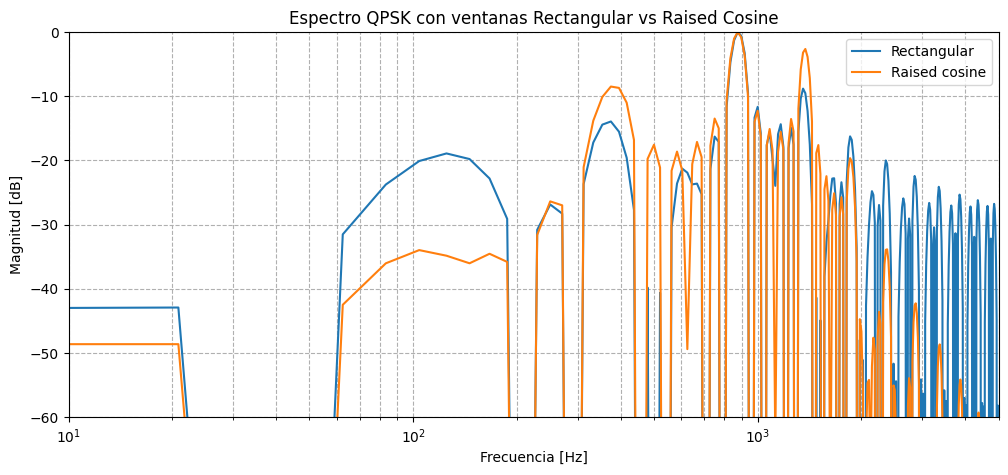

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

# --- Parámetros ---
d = np.array([0, 1, 2, 3, 0, 1])  # símbolos QPSK
T = 0.002       # duración símbolo [s]
fs = 10000      # frecuencia de muestreo [Hz]
fc = 1000       # frecuencia de portadora [Hz]

# --- Mapear símbolos a amplitudes QPSK ---
mapping = {0: 1, 1: 1j, 2: -1, 3: -1j}
a = np.array([mapping[di] for di in d])

# --- Tiempo ---
t = np.arange(0, T*len(d), 1/fs)
s = np.zeros_like(t, dtype=complex)

# --- Generar señal QPSK ---
for i, ai in enumerate(a):
    idx = (t >= i*T) & (t < (i+1)*T)
    if np.real(ai) != 0:  # par -> coseno
        s[idx] = np.real(ai) * np.cos(2*np.pi*fc*t[idx])
    else:                 # impar -> seno
        s[idx] = np.imag(ai) * np.sin(2*np.pi*fc*t[idx])

# --- Ventanas ---
rect_win = np.ones_like(t)
rc_win = np.zeros_like(t)
# Raised cosine simple para cada símbolo
hann_win = windows.hann(int(T*fs))
for i in range(len(d)):
    idx = slice(int(i*T*fs), int((i+1)*T*fs))
    rc_win[idx] = hann_win
s_rc = s * rc_win
s_rect = s * rect_win

# --- FFT ---
def compute_fft(signal, fs):
    N = len(signal)
    S = np.fft.fft(signal, n=4*N)  # zero padding para mejor resolución
    S = np.fft.fftshift(S)
    f = np.fft.fftshift(np.fft.fftfreq(4*N, 1/fs))
    S_db = 20*np.log10(np.abs(S)/np.max(np.abs(S)) + 1e-12)  # normalizado a 0 dB
    return f, S_db

f_rect, S_rect_db = compute_fft(s_rect, fs)
f_rc, S_rc_db = compute_fft(s_rc, fs)

# --- Plot ---
plt.figure(figsize=(12,5))
plt.plot(f_rect, S_rect_db, label='Rectangular')
plt.plot(f_rc, S_rc_db, label='Raised cosine')
plt.xscale('log')
plt.xlim(10, fs/2)
plt.ylim(-60, 0)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.title('Espectro QPSK con ventanas Rectangular vs Raised Cosine')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()


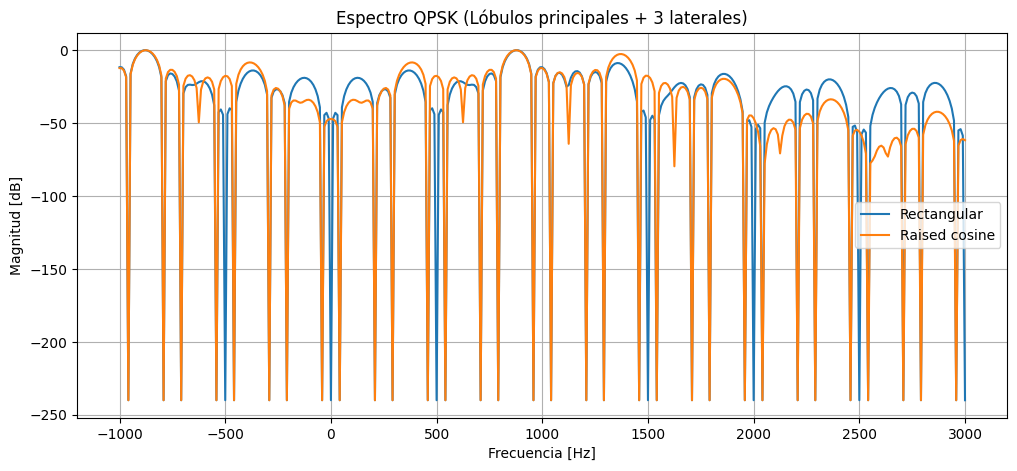

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

# --- Parámetros ---
d = np.array([0, 1, 2, 3, 0, 1])  # símbolos QPSK
T = 0.002       # duración símbolo [s]
fs = 10000      # frecuencia de muestreo [Hz]
fc = 1000       # frecuencia de portadora [Hz]

# --- Mapear símbolos a amplitudes QPSK ---
mapping = {0: 1, 1: 1j, 2: -1, 3: -1j}
a = np.array([mapping[di] for di in d])

# --- Tiempo ---
t = np.arange(0, T*len(d), 1/fs)
s = np.zeros_like(t, dtype=complex)

# --- Generar señal QPSK ---
for i, ai in enumerate(a):
    idx = (t >= i*T) & (t < (i+1)*T)
    if np.real(ai) != 0:  # par -> coseno
        s[idx] = np.real(ai) * np.cos(2*np.pi*fc*t[idx])
    else:                 # impar -> seno
        s[idx] = np.imag(ai) * np.sin(2*np.pi*fc*t[idx])

# --- Ventanas ---
rect_win = np.ones_like(t)
rc_win = np.zeros_like(t)
hann_win = windows.hann(int(T*fs))
for i in range(len(d)):
    idx = slice(int(i*T*fs), int((i+1)*T*fs))
    rc_win[idx] = hann_win
s_rect = s * rect_win
s_rc = s * rc_win

# --- FFT ---
def compute_fft(signal, fs):
    N = len(signal)
    S = np.fft.fft(signal, n=8*N)  # zero padding para mayor resolución
    S = np.fft.fftshift(S)
    f = np.fft.fftshift(np.fft.fftfreq(8*N, 1/fs))
    S_db = 20*np.log10(np.abs(S)/np.max(np.abs(S)) + 1e-12)  # normalizado
    return f, S_db

f_rect, S_rect_db = compute_fft(s_rect, fs)
f_rc, S_rc_db = compute_fft(s_rc, fs)

# --- Seleccionar banda para 3 primeros lóbulos laterales ---
# Ancho del primer lóbulo lateral aproximado: delta_f = 1/T
lateral_band = 4/T  # cubre lóbulo principal + 3 lóbulos a cada lado
mask = (f_rect >= fc - lateral_band) & (f_rect <= fc + lateral_band)

# --- Plot ---
plt.figure(figsize=(12,5))
plt.plot(f_rect[mask], S_rect_db[mask], label='Rectangular')
plt.plot(f_rc[mask], S_rc_db[mask], label='Raised cosine')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.title('Espectro QPSK (Lóbulos principales + 3 laterales)')
plt.grid(True)
plt.legend()
plt.show()


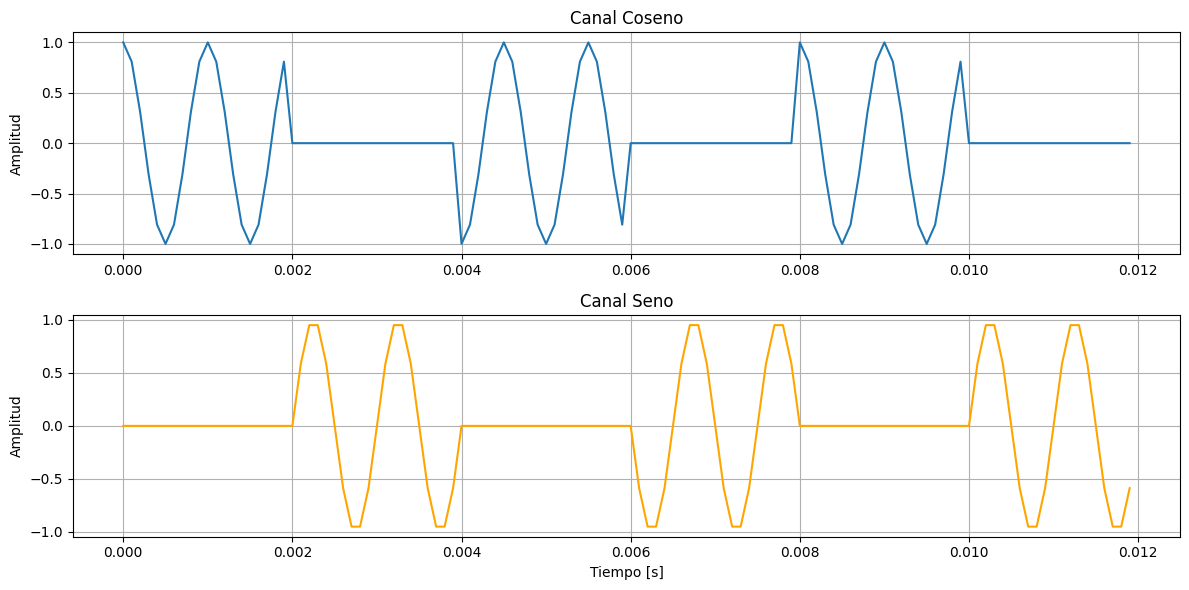

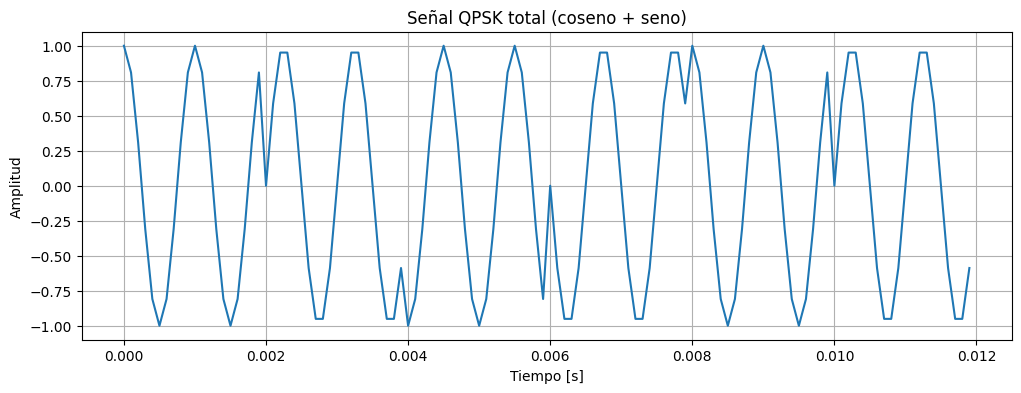

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros ---
d = np.array([0, 1, 2, 3, 0, 1])  # símbolos QPSK
T = 0.002       # duración símbolo [s]
fs = 10000      # frecuencia de muestreo [Hz]
fc = 1000       # frecuencia de portadora [Hz]

# --- Mapear símbolos ---
mapping = {0: 1, 1: 1j, 2: -1, 3: -1j}
a = np.array([mapping[di] for di in d])

# --- Tiempo ---
t = np.arange(0, T*len(d), 1/fs)
s_cos = np.zeros_like(t)
s_sin = np.zeros_like(t)

# --- Ventana rectangular ---
V = np.ones(int(T*fs))

# --- Generar señales por canal ---
for i, ai in enumerate(a):
    idx = slice(int(i*T*fs), int((i+1)*T*fs))
    if np.real(ai) != 0:  # par -> coseno
        s_cos[idx] = np.real(ai) * np.cos(2*np.pi*fc*t[idx]) * V
    else:                 # impar -> seno
        s_sin[idx] = np.imag(ai) * np.sin(2*np.pi*fc*t[idx]) * V

# --- Suma de los dos canales ---
s_total = s_cos + s_sin

# --- Gráfica canales separados ---
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(t, s_cos, label='Canal coseno (pares)')
plt.ylabel('Amplitud')
plt.title('Canal Coseno')
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(t, s_sin, label='Canal seno (impares)', color='orange')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Canal Seno')
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Gráfica suma de canales ---
plt.figure(figsize=(12,4))
plt.plot(t, s_total, label='Suma de canales')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal QPSK total (coseno + seno)')
plt.grid(True)
plt.show()


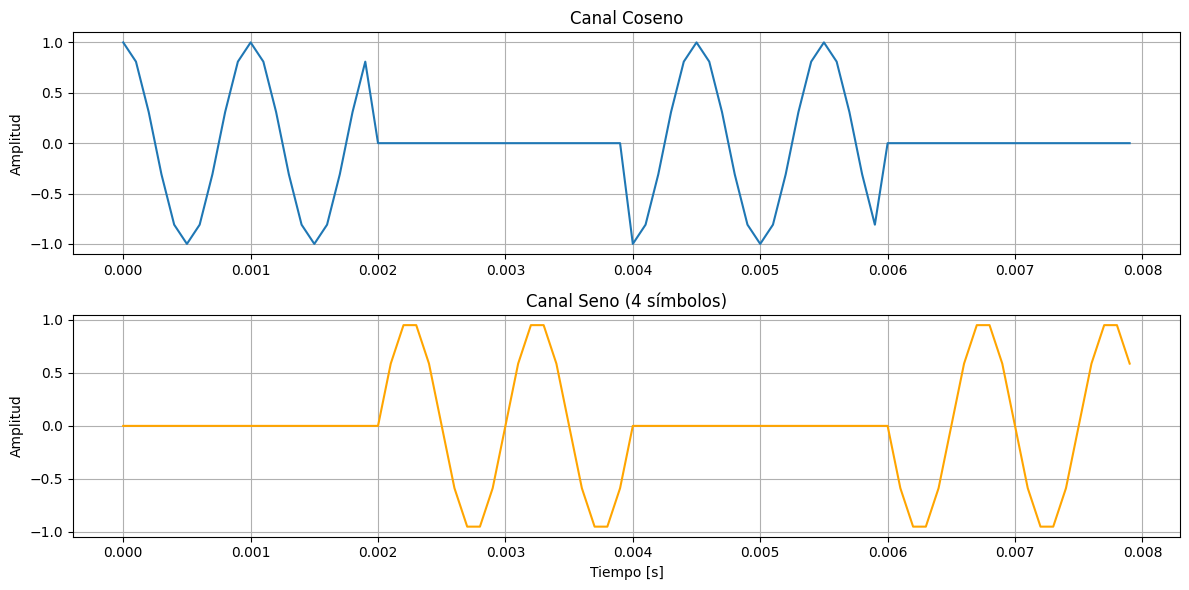

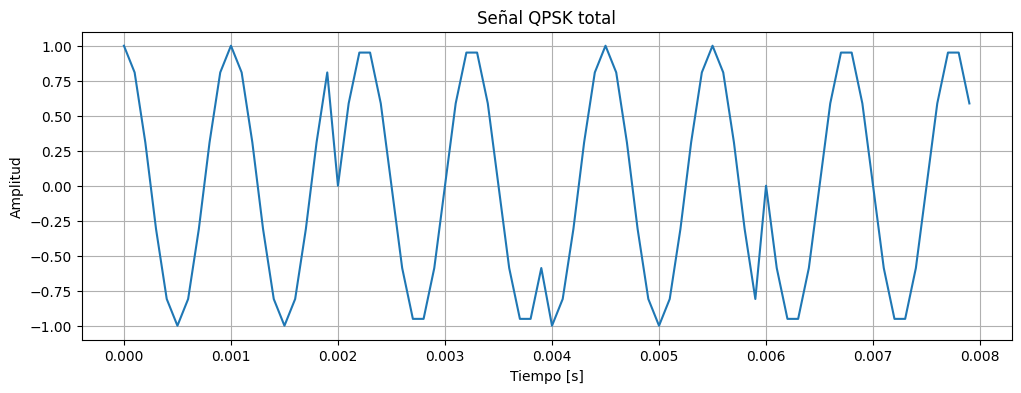

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros ---
# 8 símbolos QPSK
d = np.array([0,1, 2, 3,])
T = 0.002       # duración símbolo [s]
fs = 10000      # frecuencia de muestreo [Hz]
fc = 1000       # frecuencia de portadora [Hz]

# --- Mapear símbolos ---
mapping = {0: 1, 1: 1j, 2: -1, 3: -1j}
a = np.array([mapping[di] for di in d])

# --- Tiempo ---
t = np.arange(0, T*len(d), 1/fs)
s_cos = np.zeros_like(t)
s_sin = np.zeros_like(t)

# --- Ventana rectangular ---
V = np.ones(int(T*fs))

# --- Generar señales por canal ---
for i, ai in enumerate(a):
    idx = slice(int(i*T*fs), int((i+1)*T*fs))
    if np.real(ai) != 0:  # par -> coseno
        s_cos[idx] = np.real(ai) * np.cos(2*np.pi*fc*t[idx]) * V
    else:                 # impar -> seno
        s_sin[idx] = np.imag(ai) * np.sin(2*np.pi*fc*t[idx]) * V

# --- Suma de los dos canales ---
s_total = s_cos + s_sin

# --- Gráfica canales separados ---
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(t, s_cos, label='Canal coseno (pares)')
plt.ylabel('Amplitud')
plt.title('Canal Coseno')
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(t, s_sin, label='Canal seno (impares)', color='orange')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Canal Seno (4 símbolos)')
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Gráfica suma de canales ---
plt.figure(figsize=(12,4))
plt.plot(t, s_total, label='Suma de canales')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal QPSK total')
plt.grid(True)
plt.show()


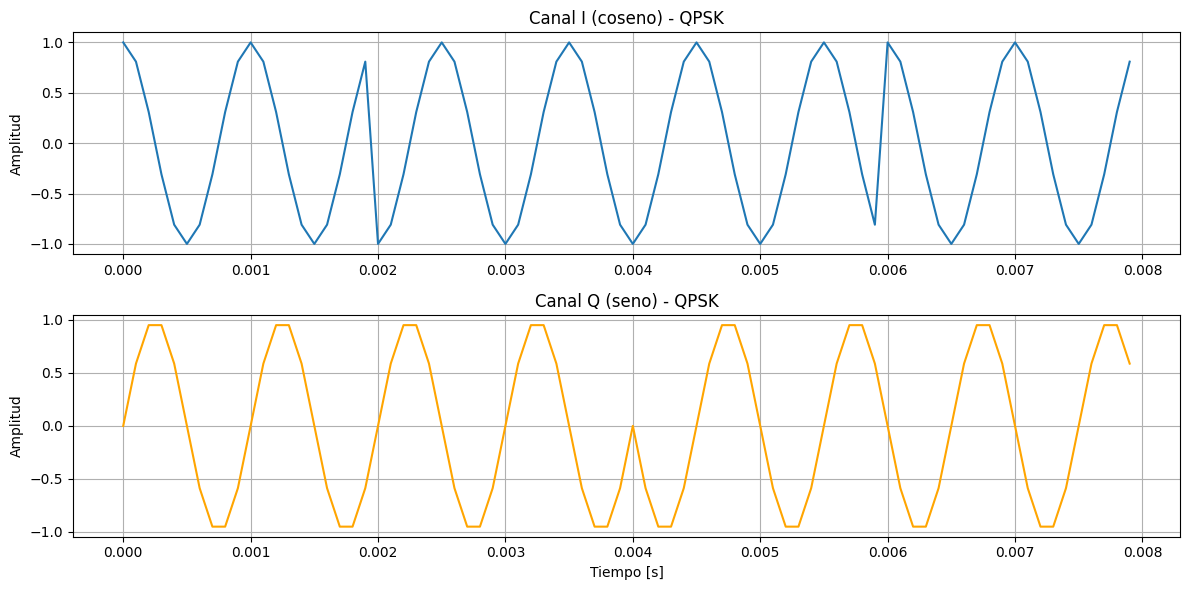

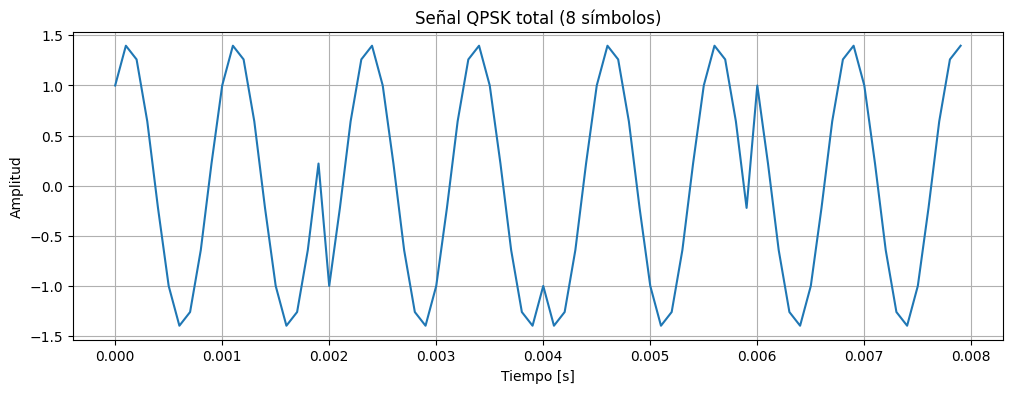

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros ---
d = np.array([0, 1, 2, 3])  # 8 símbolos
T = 0.002       # duración símbolo [s]
fs = 10000      # frecuencia de muestreo [Hz]
fc = 1000       # frecuencia de portadora [Hz]

# --- Mapear símbolos a QPSK ---
# a_i = I + jQ
mapping = {0: 1+1j, 1: -1+1j, 2: -1-1j, 3: 1-1j}
a = np.array([mapping[di] for di in d])

# --- Tiempo ---
t = np.arange(0, T*len(d), 1/fs)
s_I = np.zeros_like(t)
s_Q = np.zeros_like(t)

# --- Ventana rectangular ---
V = np.ones(int(T*fs))

# --- Generar señales I (coseno) y Q (seno) ---
for i, ai in enumerate(a):
    idx = slice(int(i*T*fs), int((i+1)*T*fs))
    s_I[idx] = np.real(ai) * np.cos(2*np.pi*fc*t[idx]) * V
    s_Q[idx] = np.imag(ai) * np.sin(2*np.pi*fc*t[idx]) * V

# --- Señal QPSK total ---
s_total = s_I + s_Q

# --- Gráfica canales separados ---
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(t, s_I, label='Canal I (coseno)')
plt.ylabel('Amplitud')
plt.title('Canal I (coseno) - QPSK')
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(t, s_Q, label='Canal Q (seno)', color='orange')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Canal Q (seno) - QPSK')
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Gráfica señal QPSK total ---
plt.figure(figsize=(12,4))
plt.plot(t, s_total, label='Señal QPSK total (I+Q)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal QPSK total (8 símbolos)')
plt.grid(True)
plt.show()


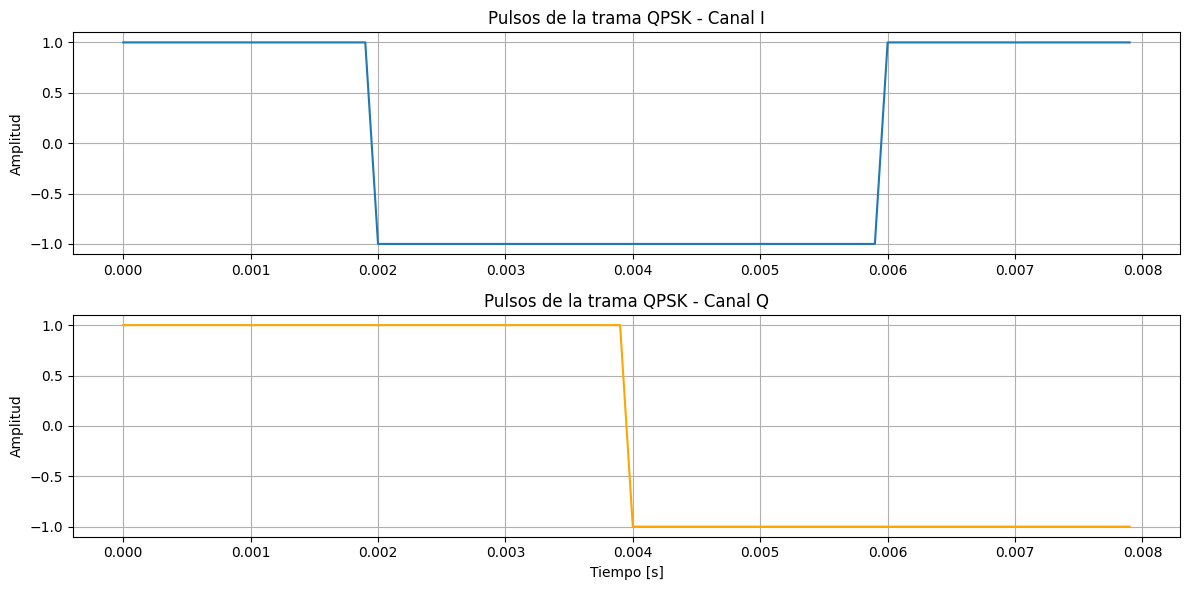

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros ---
d = np.array([0, 1, 2, 3])  # 8 símbolos
T = 0.002       # duración símbolo [s]
fs = 10000      # frecuencia de muestreo [Hz]

# --- Mapear símbolos a QPSK ---
mapping = {0: 1+1j, 1: -1+1j, 2: -1-1j, 3: 1-1j}
a = np.array([mapping[di] for di in d])

# --- Tiempo ---
t = np.arange(0, T*len(d), 1/fs)
pulse_I = np.zeros_like(t)
pulse_Q = np.zeros_like(t)

# --- Ventana rectangular ---
V = np.ones(int(T*fs))

# --- Generar pulsos I y Q ---
for i, ai in enumerate(a):
    idx = slice(int(i*T*fs), int((i+1)*T*fs))
    pulse_I[idx] = np.real(ai) * V  # pulso rectangular con amplitud I
    pulse_Q[idx] = np.imag(ai) * V  # pulso rectangular con amplitud Q

# --- Gráfica de los pulsos ---
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(t, pulse_I, label='Pulsos I (coseno)')
plt.ylabel('Amplitud')
plt.title('Pulsos de la trama QPSK - Canal I')
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(t, pulse_Q, label='Pulsos Q (seno)', color='orange')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Pulsos de la trama QPSK - Canal Q')
plt.grid(True)

plt.tight_layout()
plt.show()


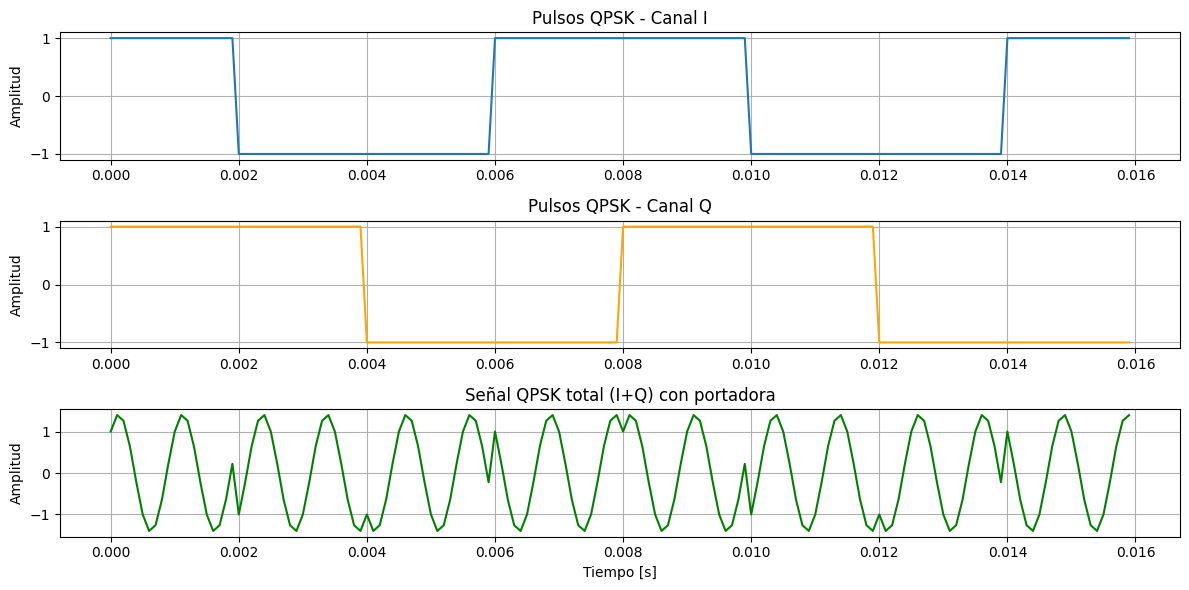

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros ---
d = np.array([0, 1, 2, 3, 0, 1, 2, 3])  # 8 símbolos
T = 0.002       # duración símbolo [s]
fs = 10000      # frecuencia de muestreo [Hz]
fc = 1000       # frecuencia de portadora [Hz]

# --- Mapear símbolos a QPSK ---
# a_i = I + jQ
mapping = {0: 1+1j, 1: -1+1j, 2: -1-1j, 3: 1-1j}
a = np.array([mapping[di] for di in d])

# --- Tiempo ---
t = np.arange(0, T*len(d), 1/fs)

# --- Inicializar señales ---
pulse_I = np.zeros_like(t)
pulse_Q = np.zeros_like(t)
s_total = np.zeros_like(t)

# --- Ventana rectangular ---
V = np.ones(int(T*fs))

# --- Generar pulsos y señal modulada ---
for i, ai in enumerate(a):
    idx = slice(int(i*T*fs), int((i+1)*T*fs))
    # Pulsos rectangulares
    pulse_I[idx] = np.real(ai) * V
    pulse_Q[idx] = np.imag(ai) * V
    # Señal QPSK modulada
    s_total[idx] = np.real(ai)*np.cos(2*np.pi*fc*t[idx]) + np.imag(ai)*np.sin(2*np.pi*fc*t[idx])

# --- Gráfica de pulsos ---
plt.figure(figsize=(12,6))
plt.subplot(3,1,1)
plt.plot(t, pulse_I, label='Pulsos I (coseno)')
plt.ylabel('Amplitud')
plt.title('Pulsos QPSK - Canal I')
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(t, pulse_Q, label='Pulsos Q (seno)', color='orange')
plt.ylabel('Amplitud')
plt.title('Pulsos QPSK - Canal Q')
plt.grid(True)

# --- Gráfica señal QPSK modulada ---
plt.subplot(3,1,3)
plt.plot(t, s_total, label='Señal QPSK modulada', color='green')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal QPSK total (I+Q) con portadora')
plt.grid(True)

plt.tight_layout()
plt.show()


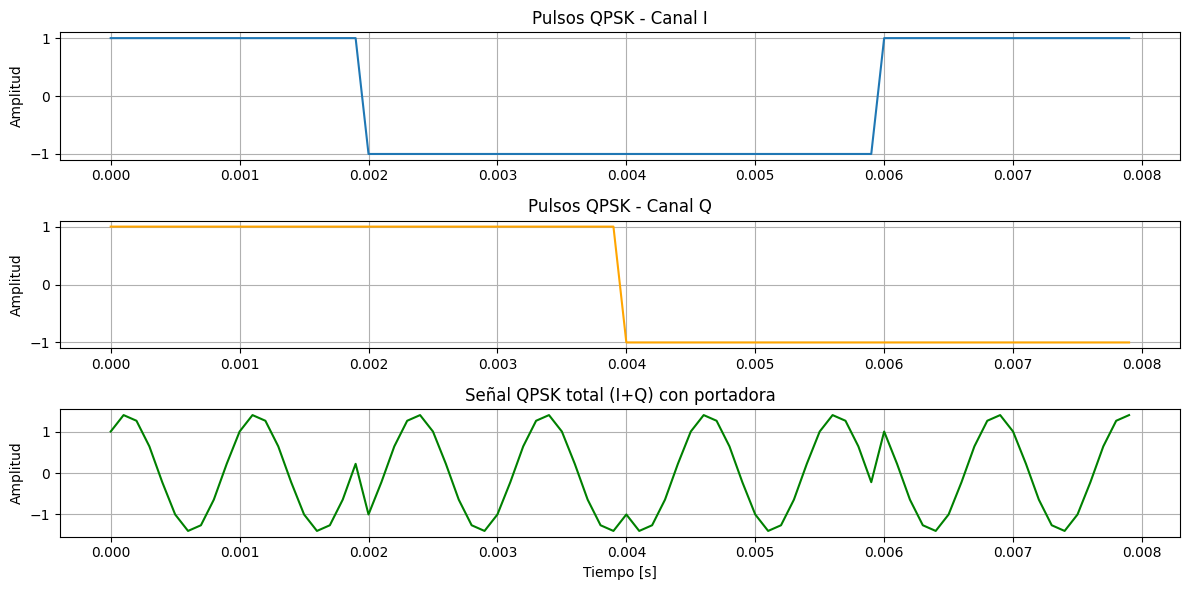

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros ---
d = np.array([0, 1, 2, 3])  # 8 símbolos
T = 0.002       # duración símbolo [s]
fs = 10000      # frecuencia de muestreo [Hz]
fc = 1000       # frecuencia de portadora [Hz]

# --- Mapear símbolos a QPSK ---
# a_i = I + jQ
mapping = {0: 1+1j, 1: -1+1j, 2: -1-1j, 3: 1-1j}
mapping={0: 1+1j, 1: -1+1j, 2: -1-1j, 3: 1-1j}
a = np.array([mapping[di] for di in d])

# --- Tiempo ---
t = np.arange(0, T*len(d), 1/fs)

# --- Inicializar señales ---
pulse_I = np.zeros_like(t)
pulse_Q = np.zeros_like(t)
s_total = np.zeros_like(t)

# --- Ventana rectangular ---
V = np.ones(int(T*fs))

# --- Generar pulsos y señal modulada ---
for i, ai in enumerate(a):
    idx = slice(int(i*T*fs), int((i+1)*T*fs))
    # Pulsos rectangulares
    pulse_I[idx] = np.real(ai) * V
    pulse_Q[idx] = np.imag(ai) * V
    # Señal QPSK modulada
    s_total[idx] = np.real(ai)*np.cos(2*np.pi*fc*t[idx]) + np.imag(ai)*np.sin(2*np.pi*fc*t[idx])

# --- Gráfica de pulsos ---
plt.figure(figsize=(12,6))
plt.subplot(3,1,1)
plt.plot(t, pulse_I, label='Pulsos I (coseno)')
plt.ylabel('Amplitud')
plt.title('Pulsos QPSK - Canal I')
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(t, pulse_Q, label='Pulsos Q (seno)', color='orange')
plt.ylabel('Amplitud')
plt.title('Pulsos QPSK - Canal Q')
plt.grid(True)

# --- Gráfica señal QPSK modulada ---
plt.subplot(3,1,3)
plt.plot(t, s_total, label='Señal QPSK modulada', color='green')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal QPSK total (I+Q) con portadora')
plt.grid(True)

plt.tight_layout()
plt.show()


# Ejercicio

William Camilo Obando Cardenas

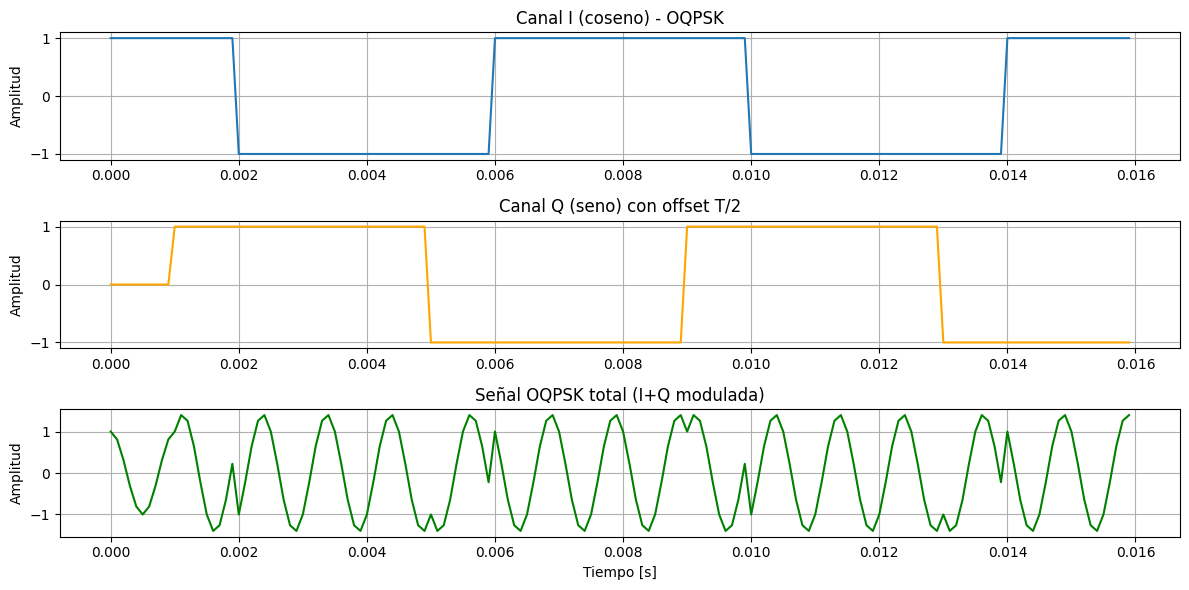

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros ---
d = np.array([0, 1, 2, 3, 0, 1, 2, 3])  # 8 símbolos
T = 0.002       # duración símbolo [s]
fs = 10000      # frecuencia de muestreo [Hz]
fc = 1000       # frecuencia de portadora [Hz]

# --- Mapear símbolos a QPSK ---
mapping = {0: 1+1j, 1: -1+1j, 2: -1-1j, 3: 1-1j}
a = np.array([mapping[di] for di in d])

# --- Tiempo ---
t = np.arange(0, T*len(d), 1/fs)

# --- Inicializar canales ---
s_I = np.zeros_like(t)
s_Q = np.zeros_like(t)

# --- Ventana rectangular ---
V = np.ones(int(T*fs))

# --- Generar canal I (sin desplazamiento) ---
for i, ai in enumerate(a):
    idx = slice(int(i*T*fs), int((i+1)*T*fs))
    s_I[idx] = np.real(ai) * V

# --- Generar canal Q (offset T/2) ---
# Para desplazar Q medio símbolo hacia adelante, añadimos T/2
offset_samples = int(T/2 * fs)
for i, ai in enumerate(a):
    idx_start = int(i*T*fs) + offset_samples
    idx_end = idx_start + int(T*fs)
    if idx_end > len(t):
        idx_end = len(t)
    idx = slice(idx_start, idx_end)
    s_Q[idx] = np.imag(ai) * V[:idx_end-idx_start]

# --- Señal total OQPSK ---
s_total = s_I * np.cos(2*np.pi*fc*t) + s_Q * np.sin(2*np.pi*fc*t)

# --- Gráficas ---
plt.figure(figsize=(12,6))
plt.subplot(3,1,1)
plt.plot(t, s_I, label='Canal I (coseno)')
plt.title('Canal I (coseno) - OQPSK')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(t, s_Q, label='Canal Q (seno) offset T/2', color='orange')
plt.title('Canal Q (seno) con offset T/2')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(t, s_total, label='Señal OQPSK total', color='green')
plt.title('Señal OQPSK total (I+Q modulada)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()


## OQPSK

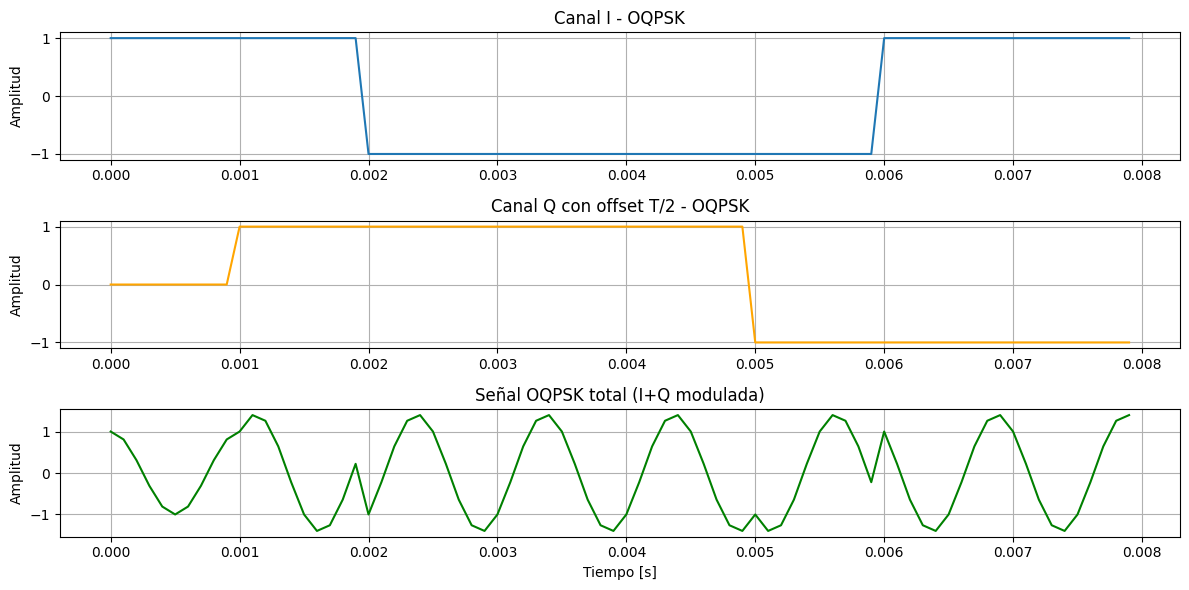

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros ---
d = np.array([0, 1, 2, 3])  # 8 símbolos
T = 0.002       # duración símbolo [s]
fs = 10000      # frecuencia de muestreo [Hz]
fc = 1000       # frecuencia de portadora [Hz]

# --- Mapear símbolos a OQPSK ---
# QPSK mapping: a_i = I + jQ
mapping = {0: 1+1j, 1: -1+1j, 2: -1-1j, 3: 1-1j}
a = np.array([mapping[di] for di in d])

# --- Tiempo ---
t = np.arange(0, T*len(d), 1/fs)

# --- Inicializar canales ---
s_I = np.zeros_like(t)
s_Q = np.zeros_like(t)

# --- Ventana rectangular ---
V = np.ones(int(T*fs))

# --- Generar canal I (sin offset) ---
for i, ai in enumerate(a):
    idx = slice(int(i*T*fs), int((i+1)*T*fs))
    s_I[idx] = np.real(ai) * V

# --- Generar canal Q con offset T/2 ---
offset_samples = int(T/2 * fs)
for i, ai in enumerate(a):
    idx_start = int(i*T*fs) + offset_samples
    idx_end = idx_start + int(T*fs)
    if idx_end > len(t):
        idx_end = len(t)
    idx = slice(idx_start, idx_end)
    s_Q[idx] = np.imag(ai) * V[:idx_end-idx_start]

# --- Señal OQPSK ---
s_total = s_I * np.cos(2*np.pi*fc*t) + s_Q * np.sin(2*np.pi*fc*t)

# --- Graficar canales y señal total ---
plt.figure(figsize=(12,6))
plt.subplot(3,1,1)
plt.plot(t, s_I, label='Canal I (coseno)')
plt.title('Canal I - OQPSK')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(t, s_Q, label='Canal Q (seno) offset T/2', color='orange')
plt.title('Canal Q con offset T/2 - OQPSK')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(t, s_total, label='Señal OQPSK total', color='green')
plt.title('Señal OQPSK total (I+Q modulada)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()


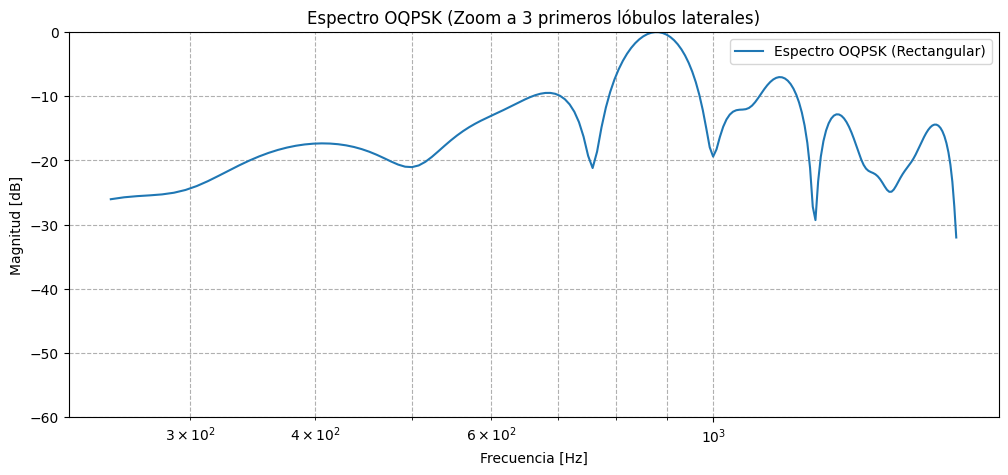

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros ---
d = np.array([0, 1, 2, 3])  # 4 símbolos
T = 0.002       # duración símbolo [s]
fs = 10000      # frecuencia de muestreo [Hz]
fc = 1000       # portadora

# --- Mapear símbolos a OQPSK ---
mapping = {0: 1+1j, 1: -1+1j, 2: -1-1j, 3: 1-1j}
a = np.array([mapping[di] for di in d])

# --- Tiempo ---
t = np.arange(0, T*len(d), 1/fs)

# --- Inicializar canales ---
s_I = np.zeros_like(t)
s_Q = np.zeros_like(t)

# --- Ventana rectangular ---
V = np.ones(int(T*fs))

# --- Canal I ---
for i, ai in enumerate(a):
    idx = slice(int(i*T*fs), int((i+1)*T*fs))
    s_I[idx] = np.real(ai) * V

# --- Canal Q con offset T/2 ---
offset_samples = int(T/2 * fs)
for i, ai in enumerate(a):
    idx_start = int(i*T*fs) + offset_samples
    idx_end = idx_start + int(T*fs)
    if idx_end > len(t):
        idx_end = len(t)
    idx = slice(idx_start, idx_end)
    s_Q[idx] = np.imag(ai) * V[:idx_end-idx_start]

# --- Señal OQPSK ---
s_total = s_I * np.cos(2*np.pi*fc*t) + s_Q * np.sin(2*np.pi*fc*t)

# --- FFT ---
N = len(s_total)
S = np.fft.fft(s_total, n=16*N)  # zero padding para mejor resolución
S = np.fft.fftshift(S)
f = np.fft.fftshift(np.fft.fftfreq(16*N, 1/fs))
S_db = 20*np.log10(np.abs(S)/np.max(np.abs(S)) + 1e-12)

# --- Zoom a 3 primeros lóbulos laterales ---
# Ancho lóbulo principal ≈ 1/(2*T)
lobe_bw = 1/(2*T)
f_min = fc - 3*lobe_bw
f_max = fc + 3*lobe_bw
mask = (f >= f_min) & (f <= f_max)

# --- Graficar espectro ---
plt.figure(figsize=(12,5))
plt.plot(f[mask], S_db[mask], label='Espectro OQPSK (Rectangular)')
plt.xscale('log')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.title('Espectro OQPSK (Zoom a 3 primeros lóbulos laterales)')
plt.ylim(-60, 0)
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()


##MSK

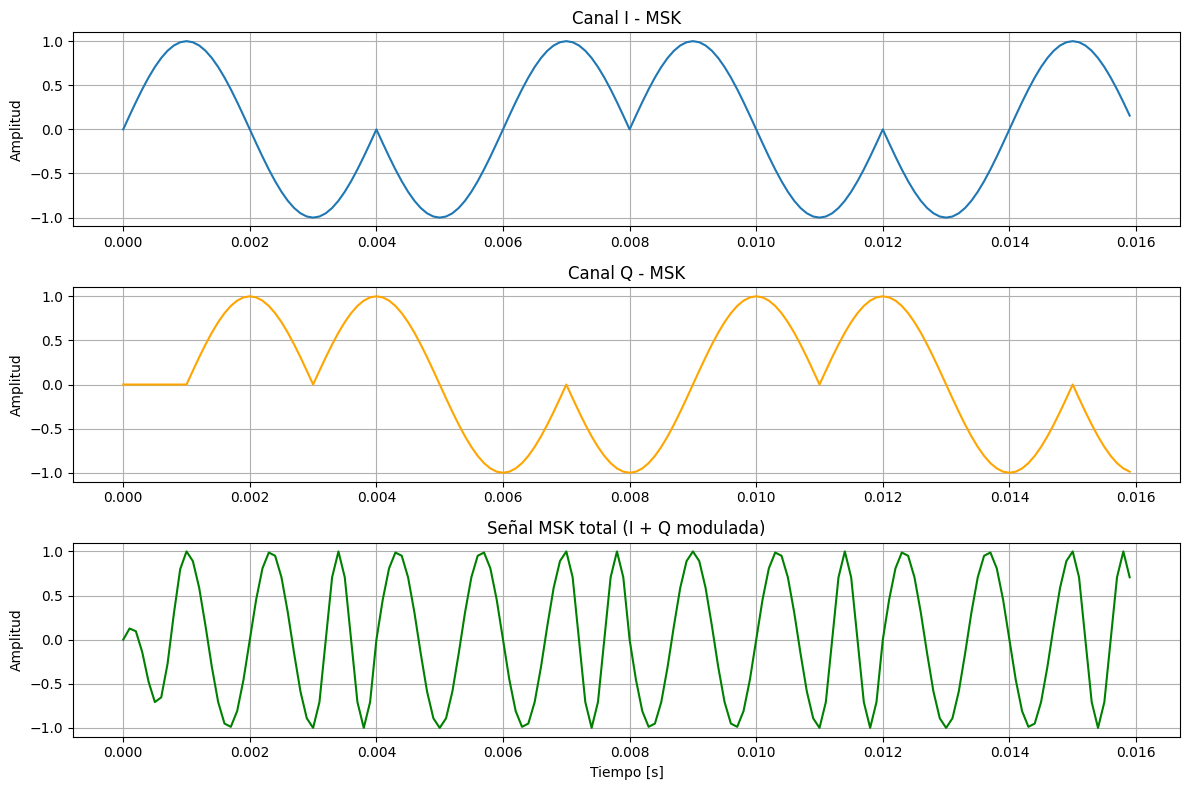

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros ---
d = np.array([0, 1, 2, 3, 0, 1, 2, 3])  # 8 símbolos
T = 0.002       # duración símbolo
fs = 10000      # frecuencia de muestreo
fc = 1000       # portadora

# --- Mapear símbolos QPSK ---
mapping = {0: 1+1j, 1: -1+1j, 2: -1-1j, 3: 1-1j}
a = np.array([mapping[di] for di in d])

# --- Tiempo ---
t = np.arange(0, T*len(d), 1/fs)
N = len(t)

# --- Generar pulsos MSK con solapamiento half-sine ---
pulse_I = np.zeros(N)
pulse_Q = np.zeros(N)

half_sine = np.sin(np.pi*np.arange(int(T*fs))/int(T*fs))  # pulso half-sine

# --- Canal I ---
for i, ai in enumerate(a):
    idx_start = int(i*T*fs)
    idx_end = idx_start + int(T*fs)
    if idx_end > N:
        idx_end = N
    pulse_I[idx_start:idx_end] += np.real(ai) * half_sine[:idx_end-idx_start]

# --- Canal Q con offset T/2 ---
offset = int(T/2*fs)
for i, ai in enumerate(a):
    idx_start = int(i*T*fs) + offset
    idx_end = idx_start + int(T*fs)
    if idx_end > N:
        idx_end = N
    pulse_Q[idx_start:idx_end] += np.imag(ai) * half_sine[:idx_end-idx_start]

# --- Señal MSK ---
s_msk = pulse_I * np.cos(2*np.pi*fc*t) + pulse_Q * np.sin(2*np.pi*fc*t)

# --- Graficar ---
plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(t, pulse_I, label='Canal I (half-sine)')
plt.title('Canal I - MSK')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(t, pulse_Q, label='Canal Q (half-sine, offset T/2)', color='orange')
plt.title('Canal Q - MSK')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(t, s_msk, label='Señal MSK total', color='green')
plt.title('Señal MSK total (I + Q modulada)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()


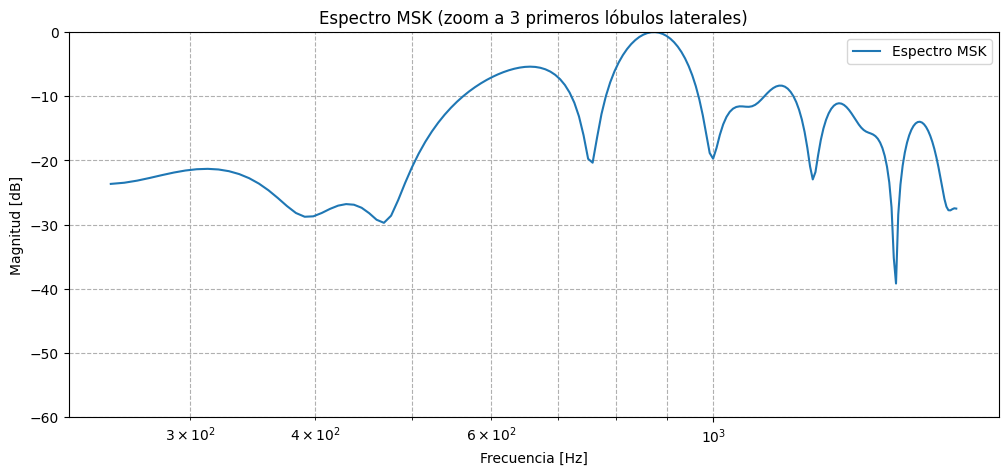

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros ---
d = np.array([0, 1, 2, 3])  # 8 símbolos
T = 0.002       # duración símbolo
fs = 10000      # frecuencia de muestreo
fc = 1000       # portadora

# --- Mapear símbolos QPSK ---
mapping = {0: 1+1j, 1: -1+1j, 2: -1-1j, 3: 1-1j}
a = np.array([mapping[di] for di in d])

# --- Tiempo ---
t = np.arange(0, T*len(d), 1/fs)
N = len(t)

# --- Generar pulsos MSK con solapamiento half-sine ---
pulse_I = np.zeros(N)
pulse_Q = np.zeros(N)
half_sine = np.sin(np.pi*np.arange(int(T*fs))/int(T*fs))  # pulso half-sine

# --- Canal I ---
for i, ai in enumerate(a):
    idx_start = int(i*T*fs)
    idx_end = idx_start + int(T*fs)
    if idx_end > N:
        idx_end = N
    pulse_I[idx_start:idx_end] += np.real(ai) * half_sine[:idx_end-idx_start]

# --- Canal Q con offset T/2 ---
offset = int(T/2*fs)
for i, ai in enumerate(a):
    idx_start = int(i*T*fs) + offset
    idx_end = idx_start + int(T*fs)
    if idx_end > N:
        idx_end = N
    pulse_Q[idx_start:idx_end] += np.imag(ai) * half_sine[:idx_end-idx_start]

# --- Señal MSK ---
s_msk = pulse_I * np.cos(2*np.pi*fc*t) + pulse_Q * np.sin(2*np.pi*fc*t)

# --- FFT ---
S = np.fft.fft(s_msk, n=16*N)  # zero padding para mejor resolución
S = np.fft.fftshift(S)
f = np.fft.fftshift(np.fft.fftfreq(16*N, 1/fs))
S_db = 20*np.log10(np.abs(S)/np.max(np.abs(S)) + 1e-12)  # normalizado a 0 dB

# --- Zoom a 3 primeros lóbulos laterales ---
# Ancho del lóbulo principal de MSK ≈ 1/(2*T)
lobe_bw = 1/(2*T)
f_min = fc - 3*lobe_bw
f_max = fc + 3*lobe_bw
mask = (f >= f_min) & (f <= f_max)

# --- Graficar espectro ---
plt.figure(figsize=(12,5))
plt.plot(f[mask], S_db[mask], label='Espectro MSK')
plt.xscale('log')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.title('Espectro MSK (zoom a 3 primeros lóbulos laterales)')
plt.ylim(-60, 0)
plt.grid(True, which='both', ls='--')
plt.legend()
plt.show()
